In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from src.data import load_prices

INTERVAL = '15m'   # change to '30m' or '15m' if you downloaded those
data = load_prices(INTERVAL)

ASSETS = ['asset_0', 'asset_1', 'asset_2']
COLORS = ['#2196F3', '#FF9800', '#4CAF50']

print(f'Shape  : {data.shape}')
print(f'From   : {data.index[0]}')
print(f'To     : {data.index[-1]}')
print(f'Columns: {list(data.columns)}')


def temporal_split(data: pd.DataFrame, train_fraction: float = 0.80):
    """
    Split cronológico sin overlap.
    """
    n = len(data)
    cut = int(n * train_fraction)
    train = data.iloc[:cut].copy()
    test = data.iloc[cut:].copy()
    return train, test

# Aquí se asume que `data` ya está cargado, con índice DatetimeIndex
data_train, data_test = temporal_split(data, train_fraction=0.80)
print(f"Train: {data_train.index.min()} a {data_train.index.max()} ({len(data_train)} filas)")
print(f"Test:  {data_test.index.min()} a {data_test.index.max()} ({len(data_test)} filas)")
print(f"\nTodo el análisis siguiente se hace SOLO sobre train.")

Shape  : (279907, 16)
From   : 2018-01-01 00:14:59.999000
To     : 2025-12-31 00:14:59.999000
Columns: ['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 'cash']
Train: 2018-01-01 00:14:59.999000 a 2024-05-26 20:44:59.999000 (223925 filas)
Test:  2024-05-26 20:59:59.999000 a 2025-12-31 00:14:59.999000 (55982 filas)

Todo el análisis siguiente se hace SOLO sobre train.


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import List, Dict

# =============================================================================
# 1. PIPELINE DE EXTRACCIÓN DE DATOS (ESTADO)
# =============================================================================

def scale_local(series: pd.Series, window_bars: int) -> pd.Series:
    """Escalado robusto rodante estricto. Lookahead = 0."""
    min_obs = max(4, window_bars // 2)
    roll = series.rolling(window=window_bars, min_periods=min_obs)
    iqr = roll.quantile(0.75) - roll.quantile(0.25)
    return (series - roll.median()) / (iqr + 1e-8)

def calc_drawdown_local(close: pd.Series, high: pd.Series, window_bars: int) -> pd.Series:
    """Calcula el drawdown rodante relativo al máximo de la ventana estricta."""
    min_obs = max(4, window_bars // 2)
    rolling_max = high.rolling(window=window_bars, min_periods=min_obs).max()
    return (close - rolling_max) / (rolling_max + 1e-8)

def build_cyclical_time_15m(timestamps: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Extrae estrictamente los relojes cíclicos del mercado.
    Valores normalizados [0, 1]. SIN tiempo absoluto, índices continuos ni años.
    """
    coords = {
        "time_min": timestamps.minute / 60.0,
        "time_hour": timestamps.hour / 24.0,
        "time_dow": timestamps.dayofweek / 7.0
    }
    return pd.DataFrame(coords, index=timestamps)

def build_complete_agent_state(data: pd.DataFrame, scales_hours: List[int] = [86, 171, 410]) -> pd.DataFrame:
    """
    Construye el tensor S_t completo: X Canales.
    - X Canales de Microestructura (18 por activo).
    - 6 Canales de Cointegración (Spreads relativos a asset_0 en 3 escalas).
    """
    frames: List[pd.DataFrame] = []
    assets: List[str] = ['asset_0', 'asset_1', 'asset_2']
    
    # 1. Tiempo Cíclico (3 dimensiones físicas)
    time_df = build_cyclical_time_15m(data.index)
    frames.append(time_df)

    # 2. Señales de Cointegración (Arbitraje relativo)
    log_p0 = np.log(data["asset_0_close"])
    log_p1 = np.log(data["asset_1_close"])
    log_p2 = np.log(data["asset_2_close"])
    
    spread_features: Dict[str, pd.Series] = {}
    
    # Táctica intradiaria (base 24h = 96 barras)
    spread_features["spread_1_0_base"] = scale_local(log_p1 - log_p0, 96)
    spread_features["spread_2_0_base"] = scale_local(log_p2 - log_p0, 96)
    
    # Escalas macro (171h y 410h)
    for h in scales_hours:
        w_bars = h * 4
        spread_features[f"spread_1_0_{h}h"] = scale_local(log_p1 - log_p0, w_bars)
        spread_features[f"spread_2_0_{h}h"] = scale_local(log_p2 - log_p0, w_bars)
        
    frames.append(pd.DataFrame(spread_features, index=data.index))

    # 3. Microestructura Táctica y Sensores Macro por Activo
    for asset in assets:
        close = data[f"{asset}_close"]
        high = data[f"{asset}_high"]
        low = data[f"{asset}_low"]
        vol = data[f"{asset}_volume"]
        tbr = data[f"{asset}_taker_buy_ratio"]
        
        # Táctica cruda (15 minutos)
        log_ret = np.log(close / close.shift(1))
        abs_ret = log_ret.abs()
        amplitude = (high - low) / close.shift(1)
        vol_roc = np.log1p(vol) - np.log1p(vol.shift(1))
        
        # Drawdown táctico base (24h)
        drawdown_base = calc_drawdown_local(close, high, window_bars=96)
        
        asset_features: Dict[str, pd.Series] = {
            f"{asset}_raw_log_ret": log_ret,
            f"{asset}_raw_abs_ret": abs_ret,
            f"{asset}_raw_amplitude": amplitude,
            f"{asset}_raw_vol_roc": vol_roc,
            f"{asset}_raw_tbr": tbr,
            f"{asset}_raw_drawdown": drawdown_base
        }
        
        # Sensores de Régimen Multiescala
        for h in scales_hours:
            w_bars = h * 4
            hours_label = f"{h}h"
            
            asset_features[f"{asset}_log_ret_{hours_label}"] = scale_local(log_ret, w_bars)
            asset_features[f"{asset}_abs_ret_{hours_label}"] = scale_local(abs_ret, w_bars)
            asset_features[f"{asset}_amplitude_{hours_label}"] = scale_local(amplitude, w_bars)
            asset_features[f"{asset}_vol_roc_{hours_label}"] = scale_local(vol_roc, w_bars)
            asset_features[f"{asset}_tbr_{hours_label}"] = scale_local(tbr, w_bars)
            asset_features[f"{asset}_drawdown_{hours_label}"] = calc_drawdown_local(close, high, w_bars)

        frames.append(pd.DataFrame(asset_features, index=data.index))
        
    return pd.concat(frames, axis=1).dropna()


In [3]:
feat_train = build_complete_agent_state(data_train)
feat_test = build_complete_agent_state(data_test)

In [4]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

class BlindfoldSubsequenceDataset(Dataset):
    """
    Generates fixed-size dense tensors of real data, paired with a dynamic boolean mask.
    The mask right-aligns the 'visible' context, simulating variable-length sequences
    without destroying RevIN normalization or using collate_fn.
    """
    def __init__(
        self, 
        features_df: pd.DataFrame, 
        max_window: int = 688, 
        min_context: int = 64, 
        max_context: int = 688, 
        epoch_size: int = 5000
    ):
        # Convert to float32 immediately to save memory and match PyTorch defaults
        self.data = features_df.values.astype(np.float32)
        self.max_window = max_window
        self.min_context = min_context
        self.max_context = min(max_context, max_window)
        self.epoch_size = epoch_size
        
        # The absolute highest index we can start at to guarantee a full max_window
        self.valid_start_limit = len(self.data) - self.max_window
        
        if self.valid_start_limit <= 0:
            raise ValueError(f"DataFrame length ({len(self.data)}) must be greater than max_window ({max_window}).")

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        # 1. Randomly pick the starting point for the FULL window
        start_idx = np.random.randint(0, self.valid_start_limit + 1)
        
        # 2. Extract the physical block of real data [max_window, features]
        # This guarantees RevIN calculates realistic means/variances.
        x_slice = self.data[start_idx : start_idx + self.max_window]
        
        # 3. Randomly decide the allowed context length for this specific sample
        context_len = np.random.randint(self.min_context, self.max_context + 1)
        
        # 4. Generate the Boolean Mask
        # True = PAD (Blindfolded / Model will replace with pad_token)
        # False = REAL (Model is allowed to attend to this)
        # We right-align the real data because trading is causal (we care about the most recent bars)
        pad_len = self.max_window - context_len
        
        mask = np.empty(self.max_window, dtype=np.bool_)
        mask[:pad_len] = True   # The oldest bars are hidden
        mask[pad_len:] = False  # The newest 'context_len' bars are visible
        
        return torch.from_numpy(x_slice), torch.from_numpy(mask)


# =============================================================================
# INTEGRATION AND USAGE
# =============================================================================

# Assuming feat_train is your 83-column DataFrame
MAX_WINDOW = 688
MIN_CONTEXT = 128  # e.g., 32 hours minimum context
BATCH_SIZE = 64
EPOCH_SIZE = 222_222

# 1. Instantiate the Dataset
train_dataset = BlindfoldSubsequenceDataset(
    features_df=feat_train,
    max_window=MAX_WINDOW,
    min_context=MIN_CONTEXT,
    max_context=MAX_WINDOW,
    epoch_size=EPOCH_SIZE
)

# 2. Create standard DataLoader (No collate_fn required)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, 
    drop_last=True,
    num_workers=0, # Adjust based on your CPU cores
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ Blindfold DataLoader Ready.")
print(f"📦 Total batches per epoch: {len(train_loader)}\n")

# 3. Verification Loop
for batch_idx, (batch_x, batch_mask) in enumerate(train_loader):
    print(f"--- Batch {batch_idx + 1} ---")
    print(f"Tensor X Shape:    {batch_x.shape} -> [Batch, {MAX_WINDOW}, 83]")
    print(f"Mask Shape:        {batch_mask.shape} -> [Batch, {MAX_WINDOW}]")
    
    # Check exactly how much history the model is allowed to see in the first 3 samples
    # We count the number of 'False' values in the mask (the real data)
    visible_lengths = (~batch_mask[:3]).sum(dim=1).tolist()
    print(f"Visible Context lengths for first 3 samples: {visible_lengths}")
    
    break

✅ Blindfold DataLoader Ready.
📦 Total batches per epoch: 3472

--- Batch 1 ---
Tensor X Shape:    torch.Size([64, 688, 83]) -> [Batch, 688, 83]
Mask Shape:        torch.Size([64, 688]) -> [Batch, 688]
Visible Context lengths for first 3 samples: [541, 343, 421]


In [ ]:
'''import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# 1. GENERADOR DE DATOS (Dataset y DataLoader)
# =============================================================================

class BlindfoldSubsequenceDataset(Dataset):
    """
    Generates fixed-size dense tensors of real data, paired with a dynamic boolean mask.
    The mask right-aligns the 'visible' context, simulating variable-length sequences
    without destroying RevIN normalization or using collate_fn.
    """
    def __init__(
        self, 
        features_df: pd.DataFrame, 
        max_window: int = 688, 
        min_context: int = 64, 
        max_context: int = 688, 
        epoch_size: int = 222_222
    ):
        # Convert to float32 immediately to save memory and match PyTorch defaults
        self.data = features_df.values.astype(np.float32)
        self.max_window = max_window
        self.min_context = min_context
        self.max_context = min(max_context, max_window)
        self.epoch_size = epoch_size
        
        # The absolute highest index we can start at to guarantee a full max_window
        self.valid_start_limit = len(self.data) - self.max_window
        
        if self.valid_start_limit <= 0:
            raise ValueError(f"DataFrame length ({len(self.data)}) must be greater than max_window ({max_window}).")

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        # 1. Randomly pick the starting point for the FULL window
        start_idx = np.random.randint(0, self.valid_start_limit + 1)
        
        # 2. Extract the physical block of real data [max_window, features]
        # This guarantees RevIN calculates realistic means/variances.
        x_slice = self.data[start_idx : start_idx + self.max_window]
        
        # 3. Randomly decide the allowed context length for this specific sample
        context_len = np.random.randint(self.min_context, self.max_context + 1)
        
        # 4. Generate the Boolean Mask
        # True = PAD (Blindfolded / Model will replace with pad_token)
        # False = REAL (Model is allowed to attend to this)
        # We right-align the real data because trading is causal (we care about the most recent bars)
        pad_len = self.max_window - context_len
        
        mask = np.empty(self.max_window, dtype=np.bool_)
        mask[:pad_len] = True   # The oldest bars are hidden
        mask[pad_len:] = False  # The newest 'context_len' bars are visible
        
        return torch.from_numpy(x_slice), torch.from_numpy(mask)


# =============================================================================
# 2. SUB-MÓDULOS NEURONALES BASE
# =============================================================================

class Time2Vec(nn.Module):
    """
    Codificador temporal continuo. 
    Separa el tiempo en una componente lineal (tendencia) y una periódica (estacionalidad).
    """
    def __init__(self, in_features: int = 3, out_dim: int = 128):
        super().__init__()
        self.k_linear = in_features 
        self.k_periodic = out_dim - in_features
        
        self.trend_proj = nn.Linear(in_features, self.k_linear)
        self.periodic_proj = nn.Linear(in_features, self.k_periodic)
        self._reset_parameters()

    def _reset_parameters(self) -> None:
        nn.init.uniform_(self.trend_proj.weight, -1.0, 1.0)
        nn.init.zeros_(self.trend_proj.bias)
        nn.init.uniform_(self.periodic_proj.weight, -1.0, 1.0)
        nn.init.zeros_(self.periodic_proj.bias)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        trend = self.trend_proj(t)
        periodic = torch.sin(self.periodic_proj(t))
        return torch.cat([trend, periodic], dim=-1)

class RevIN(nn.Module):
    """
    Reversible Instance Normalization.
    Centra la ventana local a media 0 y varianza 1 para proteger el espacio latente
    de cambios macroeconómicos y permitir un enmascaramiento con ceros coherente.
    """
    def __init__(self, num_features: int, eps: float = 1e-5, affine: bool = True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        
        if self.affine:
            self.weight = nn.Parameter(torch.ones(1, 1, num_features))
            self.bias = nn.Parameter(torch.zeros(1, 1, num_features))

    def forward(self, x: torch.Tensor, mode: str) -> torch.Tensor:
        if mode == 'norm':
            self._get_statistics(x)
            return self._normalize(x)
        elif mode == 'denorm':
            return self._denormalize(x)
        else:
            raise ValueError("El modo debe ser 'norm' o 'denorm'")

    def _get_statistics(self, x: torch.Tensor):
        self.mean = torch.mean(x, dim=1, keepdim=True)
        self.stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps)

    def _normalize(self, x: torch.Tensor):
        x = (x - self.mean) / self.stdev
        if self.affine:
            x = x * self.weight + self.bias
        return x

    def _denormalize(self, x: torch.Tensor):
        if self.affine:
            x = (x - self.bias) / (self.weight + self.eps)
        x = (x * self.stdev) + self.mean
        return x


# =============================================================================
# 3. EL CEREBRO: BACKBONE (Early Fusion Transformer Puro RL)
# =============================================================================

class QuantRobertaBody(nn.Module):
    """
    Transformer de Arbitraje Estadístico con Parcheo Temporal (PatchTST).
    Actúa exclusivamente como extractor de estado dinámico [CLS] para el agente RL.
    """
    def __init__(
        self, 
        input_features_dim: int = 80,  # IMPORTANTE: 83 totales - 3 de tiempo = 80 físicas
        time_features_dim: int = 3, 
        d_model: int = 128,  
        raw_window_bars: int = 688,  
        patch_size: int = 16,        
        stride: int = 8,             
        n_heads: int = 4, 
        n_layers: int = 2,
        dropout_rate: float = 0.1
    ):
        super().__init__()
        self.d_model = d_model
        self.patch_size = patch_size
        self.stride = stride
        self.num_patches = ((raw_window_bars - patch_size) // stride) + 1
        
        # 0. Normalización Temporal
        self.revin = RevIN(num_features=input_features_dim, affine=True)

        # 1. Compresión Espacial
        self.patch_embedding = nn.Conv1d(
            in_channels=input_features_dim, 
            out_channels=d_model, 
            kernel_size=patch_size, 
            stride=stride
        )
        
        # 2. Codificador Temporal
        self.time_encoding = Time2Vec(in_features=time_features_dim, out_dim=d_model)
        
        # 3. Tokens Estructurales
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pad_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.sep_token = nn.Parameter(torch.zeros(1, 1, d_model))

        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pad_token, std=0.02)
        nn.init.normal_(self.sep_token, std=0.02)

        # 4. Proyectores de Estado Interno (Early Fusion)
        self.portfolio_proj = nn.Linear(4, d_model)  # 4 dimensiones: asset_1, asset_2, asset_3, cash
        self.inertia_proj = nn.Linear(1, d_model)    # 1 dimensión: log(bars_since_trade + 1)
        
        # 5. Positional Encoding
        # Tamaño = num_patches + 4 ([CLS], [PORTFOLIO], [INERTIA], [SEP])
        self.positional_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 4, d_model))
        nn.init.normal_(self.positional_embedding, std=0.02)
        
        self.emb_norm = nn.LayerNorm(d_model)
        self.emb_dropout = nn.Dropout(dropout_rate)
        
        # 6. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 2, 
            dropout=dropout_rate, 
            activation="gelu", 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(
        self, 
        x: torch.Tensor, 
        t: torch.Tensor,
        portfolio_weights: torch.Tensor, # [Batch, 4]
        bars_since_trade: torch.Tensor,  # [Batch, 1]
        raw_padding_mask: torch.Tensor   # [Batch, 688]
    ) -> torch.Tensor:
        """
        x: Tensor de características físicas [Batch, 688, 80]
        t: Tensor de relojes cíclicos [Batch, 688, 3]
        portfolio_weights: Distribución actual [Batch, 4]
        bars_since_trade: Inercia [Batch, 1]
        raw_padding_mask: Booleano [Batch, 688]. True donde la barra es PAD.
        """
        B, seq_len, _ = x.shape
        device = x.device
        
        # --- 1. NORMALIZACIÓN DE INSTANCIA ---
        x_norm = self.revin(x, mode='norm')

        # --- 2. COMPRESIÓN FÍSICA ---
        x_t = x_norm.transpose(1, 2)               # [B, 80, 688]
        patched = self.patch_embedding(x_t)        # [B, 128, 85]
        tokens = patched.transpose(1, 2)           # [B, 85, 128]
        
        # --- 3. FUSIÓN TARDÍA DEL TIEMPO ---
        patch_end_indices = torch.arange(self.patch_size - 1, seq_len, self.stride, device=device)
        t_sampled = t[:, patch_end_indices, :]     # [B, 85, 3]
        tokens = tokens + self.time_encoding(t_sampled)
        
        # --- 4. LÓGICA DE PADDING ---
        mask_float = raw_padding_mask.float().unsqueeze(1) # [B, 1, 688]
        # Un parche es PAD exclusivamente si TODAS sus barras internas son PAD (promedio = 1.0)
        patch_pad_float = F.avg_pool1d(mask_float, kernel_size=self.patch_size, stride=self.stride)
        patch_padding_mask = (patch_pad_float == 1.0).squeeze(1) # [B, 85] booleano
        
        # Reemplazar parches vacíos con el pad_token limpio
        expanded_pad = self.pad_token.expand(B, self.num_patches, -1)
        tokens = torch.where(patch_padding_mask.unsqueeze(-1), expanded_pad, tokens)

        # --- 5. CREACIÓN DE TOKENS DE ESTADO ---
        port_token = self.portfolio_proj(portfolio_weights).unsqueeze(1) # [B, 1, 128]
        inertia_token = self.inertia_proj(bars_since_trade).unsqueeze(1) # [B, 1, 128]

        # --- 6. ENSAMBLAJE ESTRUCTURAL ---
        cls_tokens_batch = self.cls_token.expand(B, -1, -1) # [B, 1, 128]
        sep_tokens_batch = self.sep_token.expand(B, -1, -1) # [B, 1, 128]
        
        # Sequence: [CLS] + [PORT] + [INERTIA] + [SEP] + [PATCHES]
        sequence = torch.cat([
            cls_tokens_batch, 
            port_token, 
            inertia_token, 
            sep_tokens_batch, 
            tokens
        ], dim=1)
        
        current_seq_len = sequence.shape[1]
        sequence = sequence + self.positional_embedding[:, :current_seq_len, :]
        sequence = self.emb_dropout(self.emb_norm(sequence))
        
        # --- 7. ATENCIÓN Y ENRUTAMIENTO ---
        # Los 4 tokens estructurales (CLS, PORT, INERTIA, SEP) NUNCA son PAD (False)
        structural_pad = torch.zeros((B, 4), dtype=torch.bool, device=device)
        attn_padding_mask = torch.cat([structural_pad, patch_padding_mask], dim=1) 
        
        transformer_out = self.transformer(sequence, src_key_padding_mask=attn_padding_mask)
        
        # --- 8. EXTRACCIÓN DE ESTADO ---
        # Devolvemos exclusivamente el estado latente global (CLS) al agente RL
        return transformer_out[:, 0, :]


# =============================================================================
# 4. LAS CABEZAS INDEPENDIENTES (MLPs Ligeros)
# =============================================================================

class PPOActorHead(nn.Module):
    """
    Toma el token [CLS] (128D) y decide el ajuste del portafolio.
    """
    def __init__(self, d_model: int = 128, action_dim: int = 4, hidden_dim: int = 128):
        super().__init__()
        
        self.trunk = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        self.mu = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh() # Restringe las acciones topológicamente a [-1.0, 1.0]
        )
        # log_std paramétrico e independiente del estado para mayor estabilidad en PPO
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, cls_token: torch.Tensor) -> Normal:
        h = self.trunk(cls_token)
        mu = self.mu(h)
        
        # Clamp log_std para evitar inestabilidad numérica (explosión/colapso de varianza)
        log_std_clamped = torch.clamp(self.log_std, -20, 2)
        std = torch.exp(log_std_clamped).expand_as(mu)
        
        return Normal(mu, std)

class PPOCriticHead(nn.Module):
    """
    Toma el mismo token [CLS] y predice el Retorno Esperado (Value function V(s)).
    """
    def __init__(self, d_model: int = 128, hidden_dim: int = 128):
        super().__init__()
        
        self.trunk = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, cls_token: torch.Tensor) -> torch.Tensor:
        h = self.trunk(cls_token)
        # Devolvemos shape [Batch] en lugar de [Batch, 1]
        return self.value_head(h).squeeze(-1)


# =============================================================================
# 5. EL AGENTE MAESTRO (Early Fusion Transformer + Cabezas RL)
# =============================================================================

class QuantTradingAgent(nn.Module):
    """
    Ensambla QuantRobertaBody (Cerebro), el Actor (Manos) y el Crítico (Ojos).
    Maneja el flujo de información de PPO.
    """
    def __init__(self, backbone: QuantRobertaBody, action_dim: int = 4, hidden_dim: int = 128):
        super().__init__()
        
        # 1. El Tronco Compartido 
        self.encoder = backbone
        self.d_model = backbone.d_model
        
        # 2. Las Cabezas Independientes
        self.actor = PPOActorHead(d_model=self.d_model, action_dim=action_dim, hidden_dim=hidden_dim)
        self.critic = PPOCriticHead(d_model=self.d_model, hidden_dim=hidden_dim)

    def get_action_and_value(
        self, 
        x: torch.Tensor, 
        t: torch.Tensor, 
        portfolio_weights: torch.Tensor, 
        bars_since_trade: torch.Tensor, 
        raw_padding_mask: torch.Tensor,
        action: torch.Tensor = None 
    ):
        """
        Función central usada tanto en el rollout (step) como en el update (train).
        """
        # 1. Extraer el estado latente [Batch, 128]
        cls_state = self.encoder(
            x=x, 
            t=t, 
            portfolio_weights=portfolio_weights, 
            bars_since_trade=bars_since_trade, 
            raw_padding_mask=raw_padding_mask
        )
        
        # 2. El Crítico evalúa el estado
        value = self.critic(cls_state)
        
        # 3. El Actor genera la distribución de acciones
        dist = self.actor(cls_state)
        
        # Si estamos recolectando experiencia (rollout), muestrear acción nueva
        if action is None:
            action = dist.sample()
            
        # Calcular el log probabilty y la entropía (Requeridos para el Loss de PPO)
        log_prob = dist.log_prob(action).sum(axis=-1)
        entropy = dist.entropy().sum(axis=-1)
        
        return action, log_prob, entropy, value

    def get_value(
        self, 
        x: torch.Tensor, 
        t: torch.Tensor, 
        portfolio_weights: torch.Tensor, 
        bars_since_trade: torch.Tensor, 
        raw_padding_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Usado para hacer el bootstrap del GAE (Generalized Advantage Estimation) al final del batch.
        """
        with torch.no_grad():
            cls_state = self.encoder(
                x=x, 
                t=t, 
                portfolio_weights=portfolio_weights, 
                bars_since_trade=bars_since_trade, 
                raw_padding_mask=raw_padding_mask
            )
            return self.critic(cls_state)'''

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.utils.data import Dataset, DataLoader
import gymnasium as gym
from gymnasium import spaces
from typing import Tuple, Dict, Any, Optional



# =============================================================================
# 0. GENERADOR DE DATOS (Dataset y DataLoader)
# =============================================================================

class BlindfoldSubsequenceDataset(Dataset):
    """
    Generates fixed-size dense tensors of real data, paired with a dynamic boolean mask.
    The mask right-aligns the 'visible' context, simulating variable-length sequences
    without destroying RevIN normalization or using collate_fn.
    """
    def __init__(
        self, 
        features_df: pd.DataFrame, 
        max_window: int = 688, 
        min_context: int = 64, 
        max_context: int = 688, 
        epoch_size: int = 222_222
    ):
        # Convert to float32 immediately to save memory and match PyTorch defaults
        self.data = features_df.values.astype(np.float32)
        self.max_window = max_window
        self.min_context = min_context
        self.max_context = min(max_context, max_window)
        self.epoch_size = epoch_size
        
        # The absolute highest index we can start at to guarantee a full max_window
        self.valid_start_limit = len(self.data) - self.max_window
        
        if self.valid_start_limit <= 0:
            raise ValueError(f"DataFrame length ({len(self.data)}) must be greater than max_window ({max_window}).")

    def __len__(self):
        return self.epoch_size

    def __getitem__(self, idx):
        # 1. Randomly pick the starting point for the FULL window
        start_idx = np.random.randint(0, self.valid_start_limit + 1)
        
        # 2. Extract the physical block of real data [max_window, features]
        # This guarantees RevIN calculates realistic means/variances.
        x_slice = self.data[start_idx : start_idx + self.max_window]
        
        # 3. Randomly decide the allowed context length for this specific sample
        context_len = np.random.randint(self.min_context, self.max_context + 1)
        
        # 4. Generate the Boolean Mask
        # True = PAD (Blindfolded / Model will replace with pad_token)
        # False = REAL (Model is allowed to attend to this)
        # We right-align the real data because trading is causal (we care about the most recent bars)
        pad_len = self.max_window - context_len
        
        mask = np.empty(self.max_window, dtype=np.bool_)
        mask[:pad_len] = True   # The oldest bars are hidden
        mask[pad_len:] = False  # The newest 'context_len' bars are visible
        
        return torch.from_numpy(x_slice), torch.from_numpy(mask)
    

# =============================================================================
# 1. CORE NEURAL MODULES
# =============================================================================

class Time2Vec(nn.Module):
    """Continuous time encoding: linear trend + periodic seasonality."""
    def __init__(self, in_features: int = 3, out_dim: int = 128):
        super().__init__()
        self.k_linear = in_features 
        self.k_periodic = out_dim - in_features
        
        self.trend_proj = nn.Linear(in_features, self.k_linear)
        self.periodic_proj = nn.Linear(in_features, self.k_periodic)
        
        nn.init.uniform_(self.trend_proj.weight, -1.0, 1.0)
        nn.init.zeros_(self.trend_proj.bias)
        nn.init.uniform_(self.periodic_proj.weight, -1.0, 1.0)
        nn.init.zeros_(self.periodic_proj.bias)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        trend = self.trend_proj(t)
        periodic = torch.sin(self.periodic_proj(t))
        return torch.cat([trend, periodic], dim=-1)

class RevIN(nn.Module):
    """Reversible Instance Normalization to protect against macro regime shifts."""
    def __init__(self, num_features: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(1, 1, num_features))
        self.bias = nn.Parameter(torch.zeros(1, 1, num_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = torch.mean(x, dim=1, keepdim=True)
        stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps)
        x_norm = (x - mean) / stdev
        return (x_norm * self.weight) + self.bias


# =============================================================================
# 2. QUANT ROBERTA BACKBONE (Early Fusion)
# =============================================================================

class QuantRobertaBody(nn.Module):
    """
    The Dynamic Feature Extractor.
    Processes live sequences and internal portfolio states simultaneously.
    """
    def __init__(
        self, 
        input_features_dim: int = 80, 
        time_features_dim: int = 3, 
        d_model: int = 128,  
        raw_window_bars: int = 688,  
        patch_size: int = 16,        
        stride: int = 8,             
        n_heads: int = 4, 
        n_layers: int = 2,
        dropout_rate: float = 0.0
    ):
        super().__init__()
        self.d_model = d_model
        self.patch_size = patch_size
        self.stride = stride
        self.num_patches = ((raw_window_bars - patch_size) // stride) + 1
        
        self.revin = RevIN(num_features=input_features_dim)
        self.patch_embedding = nn.Conv1d(
            in_channels=input_features_dim, out_channels=d_model, 
            kernel_size=patch_size, stride=stride
        )
        self.time_encoding = Time2Vec(in_features=time_features_dim, out_dim=d_model)
        
        # Structural Tokens
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pad_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.sep_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pad_token, std=0.02)
        nn.init.normal_(self.sep_token, std=0.02)

        # Early Fusion Projections (Internal Agent State)
        self.portfolio_proj = nn.Linear(4, d_model)  
        self.inertia_proj = nn.Linear(1, d_model)    
        
        self.positional_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 4, d_model))
        nn.init.normal_(self.positional_embedding, std=0.02)
        
        self.emb_norm = nn.LayerNorm(d_model)
        self.emb_dropout = nn.Dropout(dropout_rate)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 2, 
            dropout=dropout_rate, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(
        self, 
        x: torch.Tensor, 
        t: torch.Tensor,
        portfolio_weights: torch.Tensor, 
        bars_since_trade: torch.Tensor,  
        raw_padding_mask: torch.Tensor   
    ) -> torch.Tensor:
        
        B, seq_len, _ = x.shape
        device = x.device
        
        x_norm = self.revin(x)
        patched = self.patch_embedding(x_norm.transpose(1, 2)).transpose(1, 2)
        
        patch_end_indices = torch.arange(self.patch_size - 1, seq_len, self.stride, device=device)
        tokens = patched + self.time_encoding(t[:, patch_end_indices, :])
        
        # Padding Logic
        mask_float = raw_padding_mask.float().unsqueeze(1) 
        patch_pad_float = F.avg_pool1d(mask_float, kernel_size=self.patch_size, stride=self.stride)
        patch_padding_mask = (patch_pad_float == 1.0).squeeze(1) 
        
        expanded_pad = self.pad_token.expand(B, self.num_patches, -1)
        tokens = torch.where(patch_padding_mask.unsqueeze(-1), expanded_pad, tokens)

        # Token Assembly
        port_token = self.portfolio_proj(portfolio_weights).unsqueeze(1) 
        inertia_token = self.inertia_proj(bars_since_trade).unsqueeze(1) 

        cls_tokens = self.cls_token.expand(B, -1, -1) 
        sep_tokens = self.sep_token.expand(B, -1, -1) 
        
        sequence = torch.cat([cls_tokens, port_token, inertia_token, sep_tokens, tokens], dim=1)
        
        current_seq_len = sequence.shape[1]
        sequence = sequence + self.positional_embedding[:, :current_seq_len, :]
        sequence = self.emb_dropout(self.emb_norm(sequence))
        
        structural_pad = torch.zeros((B, 4), dtype=torch.bool, device=device)
        attn_padding_mask = torch.cat([structural_pad, patch_padding_mask], dim=1) 
        
        transformer_out = self.transformer(sequence, src_key_padding_mask=attn_padding_mask)
        return transformer_out[:, 0, :]


# =============================================================================
# 3. PPO HEADS & MASTER AGENT
# =============================================================================

class PPOActorHead(nn.Module):
    def __init__(self, d_model: int = 128, action_dim: int = 3, hidden_dim: int = 128):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(d_model, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
        )
        self.mu = nn.Sequential(nn.Linear(hidden_dim, action_dim), nn.Tanh())
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, cls_token: torch.Tensor) -> Normal:
        mu = self.mu(self.trunk(cls_token))
        std = torch.exp(torch.clamp(self.log_std, -20, 2)).expand_as(mu)
        return Normal(mu, std)

class PPOCriticHead(nn.Module):
    def __init__(self, d_model: int = 128, hidden_dim: int = 128):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(d_model, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
        )
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, cls_token: torch.Tensor) -> torch.Tensor:
        return self.value_head(self.trunk(cls_token)).squeeze(-1)

class QuantTradingAgent(nn.Module):
    """
    Master wrapper combining the Backbone and RL Heads.
    NOTE: We share the Transformer backbone to save GPU VRAM, 
    but split the final logic into two independent MLPs.
    """
    def __init__(self, backbone: QuantRobertaBody, action_dim: int = 3, hidden_dim: int = 128):
        super().__init__()
        self.encoder = backbone
        self.actor = PPOActorHead(d_model=backbone.d_model, action_dim=action_dim, hidden_dim=hidden_dim)
        self.critic = PPOCriticHead(d_model=backbone.d_model, hidden_dim=hidden_dim)

    def get_action_and_value(self, x, t, portfolio_weights, bars_since_trade, raw_padding_mask, action=None):
        cls_state = self.encoder(x, t, portfolio_weights, bars_since_trade, raw_padding_mask)
        value = self.critic(cls_state)
        dist = self.actor(cls_state)
        
        if action is None:
            action = dist.sample()
            
        return action, dist.log_prob(action).sum(-1), dist.entropy().sum(-1), value

    def get_value(self, x, t, portfolio_weights, bars_since_trade, raw_padding_mask):
        with torch.no_grad():
            cls_state = self.encoder(x, t, portfolio_weights, bars_since_trade, raw_padding_mask)
            return self.critic(cls_state)


# =============================================================================
# 4. COMPOSABLE ENVIRONMENT
# =============================================================================
class TransformerTradingEnv(gym.Env):
    """
    Maintains the chronological sequence and yields raw time-series blocks
    as dictionaries for the Transformer to process live.
    """
    def __init__(
        self, 
        features_df: pd.DataFrame, 
        close_prices: np.ndarray, 
        max_window: int = 192, 
        initial_cash: float = 10_000.0, 
        tc_bps: float = 10.0,
        episode_length: int = 2048
    ):
        super().__init__()
        
        self.max_window = max_window
        self.initial_cash = initial_cash
        self.tc_multiplier = 1.0 - (tc_bps / 10_000.0)
        self.discretization_param = 5
        self.episode_length = episode_length
        
        time_cols = [c for c in features_df.columns if c.startswith('time_')]
        feat_cols = [c for c in features_df.columns if not c.startswith('time_')]
        
        self.t_data = features_df[time_cols].values.astype(np.float32)
        self.x_data = features_df[feat_cols].values.astype(np.float32)
        self.prices = close_prices.astype(np.float32) # [N, 3] Expected format for asset 0,1,2
        
        self.max_steps = len(self.x_data) - 1
        
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        # Uses Dict Space to naturally pass multimodal data
        self.observation_space = spaces.Dict({
            "x": spaces.Box(low=-np.inf, high=np.inf, shape=(max_window, len(feat_cols)), dtype=np.float32),
            "t": spaces.Box(low=-np.inf, high=np.inf, shape=(max_window, len(time_cols)), dtype=np.float32),
            "portfolio": spaces.Box(low=0.0, high=1.0, shape=(4,), dtype=np.float32),
            "inertia": spaces.Box(low=0.0, high=np.inf, shape=(1,), dtype=np.float32),
            "mask": spaces.Box(low=0, high=1, shape=(max_window,), dtype=np.bool_)
        })

    def reset(self, *, seed=None, options=None) -> Tuple[Dict[str, np.ndarray], dict]:
        super().reset(seed=seed)
        
        # 1. Random historical start point
        min_start = self.max_window
        max_start = self.max_steps - self.episode_length - 1
        self._t = np.random.randint(min_start, max_start)
        self._end_step = self._t + self.episode_length
        
        # --- THE CORRECTED FIX: NATIVE RANDOM STATE ---
        # 1. Generate a totally random action matching your action space [-1.0 to 1.0]
        random_action = np.random.uniform(-1.0, 1.0, size=(3,))
        # The agent will wake up holding at least 70% Cash, protecting it from flash crashes.
        random_action *= 0.3
        
        # 2. Temporarily set weights to pure zero. 
        # This guarantees the random action will pass your 0.25 Inertia Filter.
        self._weights = np.zeros(4, dtype=np.float32)
        
        # 3. Pass the random action through your EXACT mathematical pipeline.
        # This automatically applies your Quantization, L1 projection, and Cash logic!
        self._weights = self._apply_action(random_action)
        
        # 4. Randomize inertia: The agent wakes up believing it has held this 
        # valid random portfolio anywhere from 0 to 48 bars.
        self._bars_since_trade = float(np.random.randint(0, 48))
        # ---------------------------------------------
        
        self._value = float(self.initial_cash)
        
        return self._get_obs(), {}

    def _get_obs(self) -> Dict[str, np.ndarray]:
        start_idx = self._t - self.max_window + 1
        end_idx = self._t + 1
        
        return {
            "x": self.x_data[start_idx:end_idx],
            "t": self.t_data[start_idx:end_idx],
            "portfolio": np.nan_to_num(self._weights, nan=0.0).astype(np.float32),
            "inertia": np.array([np.log1p(self._bars_since_trade)], dtype=np.float32),
            "mask": np.zeros(self.max_window, dtype=np.bool_) # No padding during live RL
        }

    def _apply_action(self, action: np.ndarray) -> np.ndarray:
        a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        
        # 1. Discretization: Destroys microscopic noise
        a = np.round(a * self.discretization_param) / self.discretization_param
        
        # 2. L1 Projection: Cap gross exposure at 100%
        gross_exposure = np.sum(np.abs(a))
        if gross_exposure > 1.0:
            a = a / gross_exposure 
            
        # 3. Float32 Shielding
        w_cash = float(1.0 - np.sum(a))
        w_cash = max(0.0, w_cash) 
        
        target_w = np.array([a[0], a[1], a[2], w_cash], dtype=np.float32)
        target_w = target_w / np.sum(target_w) # Force perfect sum to 1.0
        
        # 4. Inertia Filter: Rotations < 25% are ignored to save commissions
        current_w_safe = np.nan_to_num(self._weights, nan=0.0)
        turnover_intention = float(np.sum(np.abs(target_w - current_w_safe)))
        if turnover_intention < 0.25:  
            return self._weights.copy()
            
        return target_w

    def _reward_phase_1(self, prev_value: float, curr_value: float) -> float:
        # Calculate raw BPS reward
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        if reward_bps < 0:
            reward_bps *= 2.5
        return float(np.clip(reward_bps, -75.0, 75.0))
    
    def _reward(self, prev_value: float, curr_value: float) -> float:
        # Calculate raw BPS reward
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        
        PENALTY_MULT = 1.5
        THRESHOLD_BPS = -15.0 
        
        if reward_bps < THRESHOLD_BPS:
            # Calculate how far past the threshold the agent fell
            excess_loss = reward_bps - THRESHOLD_BPS
            
            # Apply the penalty ONLY to the excess damage
            reward_bps = THRESHOLD_BPS + (excess_loss * PENALTY_MULT)
            
        return float(np.clip(reward_bps, -75.0, 75.0))

    def step(self, action: np.ndarray) -> Tuple[Dict[str, np.ndarray], float, bool, bool, dict]:
        prev_weights = self._weights.copy()
        prev_value = self._value
        
        # 1. Update Portfolio
        target_weights = self._apply_action(action)
        turnover = float(np.sum(np.abs(np.nan_to_num(target_weights, nan=0.0) - np.nan_to_num(prev_weights, nan=0.0))))
        
        # If the inertia filter blocked the trade, turnover is practically 0
        if turnover < 1e-4:
            self._bars_since_trade += 1.0
            turnover = 0.0
        else:
            self._weights = target_weights
            self._bars_since_trade = 0.0
            
        # 2. Advance Time 
        self._t += 1
        
        price_prev = self.prices[self._t - 1]
        price_curr = self.prices[self._t]
        returns = (price_curr - price_prev) / (price_prev + 1e-8)
        
        port_return = np.sum(self._weights[:3] * returns)
        
        self._value = prev_value * (1.0 + port_return)
        if turnover > 0: 
            self._value *= self.tc_multiplier 
        
        # 3. Reward Calculation & Neural Scaling
        raw_reward = self._reward(prev_value, self._value)
        
        # SCALING FACTOR: Keeps the reward between [-0.75, 0.75]. Fixes VLoss explosion!
        scaled_reward = raw_reward / 100.0 
        
        # 4. Termination
        truncated = bool(self._t >= self._end_step)
        
        # Stop-Loss: If it loses 80% of its money (from 10k to 2k)
        if self._value < 2000.0:
            truncated = True
        
        terminated = False 
            
        # Pass raw_reward in info dict so we can read it natively in TensorBoard
        return self._get_obs(), scaled_reward, terminated, truncated, {"raw_reward": raw_reward}


# =============================================================================
# 5. MULTIMODAL BUFFER & PPO ENGINE
# =============================================================================
import time
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter

class MultimodalRolloutBuffer:
    """Stores full 3D sequences directly on the GPU."""
    def __init__(self, size: int, max_window: int, x_dim: int, t_dim: int, device: torch.device):
        self.device = device
        self.x = torch.zeros((size, max_window, x_dim), dtype=torch.float32, device=device)
        self.t = torch.zeros((size, max_window, t_dim), dtype=torch.float32, device=device)
        self.mask = torch.zeros((size, max_window), dtype=torch.bool, device=device)
        self.portfolio = torch.zeros((size, 4), dtype=torch.float32, device=device)
        self.inertia = torch.zeros((size, 1), dtype=torch.float32, device=device)
        
        self.actions = torch.zeros((size, 3), dtype=torch.float32, device=device)
        self.log_probs = torch.zeros(size, dtype=torch.float32, device=device)
        self.rewards = torch.zeros(size, dtype=torch.float32, device=device)
        self.values = torch.zeros(size, dtype=torch.float32, device=device)
        self.dones = torch.zeros(size, dtype=torch.float32, device=device)
        self.ptr = 0

    def add(self, obs: Dict[str, np.ndarray], action: np.ndarray, log_prob: float, reward: float, value: float, done: bool):
        i = self.ptr
        self.x[i] = torch.from_numpy(obs["x"]).to(self.device)
        self.t[i] = torch.from_numpy(obs["t"]).to(self.device)
        self.mask[i] = torch.from_numpy(obs["mask"]).to(self.device)
        self.portfolio[i] = torch.from_numpy(obs["portfolio"]).to(self.device)
        self.inertia[i] = torch.from_numpy(obs["inertia"]).to(self.device)
        
        self.actions[i] = torch.from_numpy(action).to(self.device)
        self.log_probs[i] = log_prob
        self.rewards[i] = reward
        self.values[i] = value
        self.dones[i] = float(done)
        self.ptr += 1

def compute_gae(rewards: torch.Tensor, values: torch.Tensor, dones: torch.Tensor, last_value: torch.Tensor, gamma: float = 0.99, lam: float = 0.95):
    size = rewards.size(0)
    advantages = torch.zeros(size, dtype=torch.float32, device=rewards.device)
    gae = 0.0
    for t in reversed(range(size)):
        next_value = last_value if t == size - 1 else values[t + 1]
        next_non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * next_non_terminal - values[t]
        gae = delta + gamma * lam * next_non_terminal * gae
        advantages[t] = gae
    return advantages, advantages + values


class EndToEndPPOAgent:
    """
    Orchestrates the entire process with full telemetry, tracking KL divergence, 
    entropy, and financial metrics via TensorBoard.
    """
    def __init__(self, agent: QuantTradingAgent, rollout_len: int = 512, log_dir: str = "runs"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.agent = agent.to(self.device)
        self.rollout_len = rollout_len
        
        self.lr = 5e-5 #1e-4 for phase1
        self.gamma = 0.99
        self.lam = 0.95
        self.clip_eps = 0.2
        self.epochs_ppo = 4
        self.minibatch_size = 64
        
        self.c_entropy = 0.001
        self.optimizer = torch.optim.AdamW(self.agent.parameters(), lr=self.lr)
        self.global_step = 0
        
        # --- TELEMETRY SETUP ---
        self.run_name = f"QuantRoberta_PPO_{int(time.time())}"
        self.writer = SummaryWriter(Path(log_dir) / self.run_name)
        print(f"📡 Telemetry active. Run name: {self.run_name}")

    def _batch_obs(self, obs: Dict[str, np.ndarray]) -> Dict[str, torch.Tensor]:
        return {k: torch.from_numpy(v).unsqueeze(0).to(self.device) for k, v in obs.items()}
    
    def train(self, env: TransformerTradingEnv, n_steps: int = 100_000):
        from collections import deque # <--- AÑADIDO: Para la media móvil
        
        n_iters = max(1, n_steps // self.rollout_len)
        obs, _ = env.reset()
        
        x_dim = env.observation_space["x"].shape[1]
        t_dim = env.observation_space["t"].shape[1]

        self.best_ret = -float('inf')
        
        # --- EL FIX: Ventana móvil para retornos estadísticamente significativos ---
        rolling_returns = deque(maxlen=20) 
        
        # =====================================================================
        # 🚨 BUG CRÍTICO CORREGIDO: MOVIDOS AFUERA DEL BUCLE
        # Para no borrar el progreso a la mitad del episodio.
        # =====================================================================
        current_ep_return, current_ep_length = 0.0, 0

        # --- EARLY STOPPING CONFIGURATION ---
        kl_patience = 10           # Iteraciones consecutivas necesarias para detener
        kl_threshold = 1e-4        # Si el KL cae por debajo de esto, consideramos que no aprende
        kl_collapse_counter = 0    # Contador actual

        for it in range(n_iters):
            buffer = MultimodalRolloutBuffer(self.rollout_len, env.max_window, x_dim, t_dim, self.device)
            self.agent.eval()

            # Solo reiniciamos las listas locales del rollout
            ep_returns, ep_lengths, final_portfolios = [], [], []

            # 1. Rollout Collection
            for _ in range(self.rollout_len):
                self.global_step += 1
                t_obs = self._batch_obs(obs)
                with torch.no_grad():
                    action, log_prob, _, value = self.agent.get_action_and_value(
                        t_obs["x"], t_obs["t"], t_obs["portfolio"], t_obs["inertia"], t_obs["mask"]
                    )
                
                a_np = action.squeeze(0).cpu().numpy()
                next_obs, reward, terminated, truncated, info = env.step(a_np)
                done = terminated or truncated

                # Network learns from scaled 'reward'
                buffer.add(obs, a_np, log_prob.item(), reward, value.item(), done)
                
                # YOU see the real BPS return
                real_reward = info.get("raw_reward", reward * 100.0)
                current_ep_return += real_reward 
                current_ep_length += 1

                if done:
                    ep_returns.append(current_ep_return)
                    
                    # --- AÑADIR A LA HISTORIA MÓVIL ---
                    rolling_returns.append(current_ep_return) 
                    
                    ep_lengths.append(current_ep_length)
                    final_portfolios.append(env._value)  
                    
                    # Resetear contadores solo cuando el episodio realmente termina
                    current_ep_return, current_ep_length = 0.0, 0
                    next_obs, _ = env.reset()
                
                obs = next_obs

            # 2. Generalized Advantage Estimation (GAE)
            with torch.no_grad():
                t_obs = self._batch_obs(obs)
                last_value = self.agent.get_value(
                    t_obs["x"], t_obs["t"], t_obs["portfolio"], t_obs["inertia"], t_obs["mask"]
                ).squeeze(0)
                
            advantages, returns = compute_gae(buffer.rewards, buffer.values, buffer.dones, last_value, self.gamma, self.lam)
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # 3. Network Update (End-to-End)
            self.agent.train()
            idx = np.arange(self.rollout_len)
            
            # --- UPDATE TRACKERS ---
            clip_fractions, approx_kls = [], []
            actor_losses, value_losses, entropies = [], [], []
            
            for _ in range(self.epochs_ppo):
                np.random.shuffle(idx)
                for start in range(0, self.rollout_len, self.minibatch_size):
                    mb = idx[start:start + self.minibatch_size]
                    
                    _, new_lp, entropy, value = self.agent.get_action_and_value(
                        buffer.x[mb], buffer.t[mb], buffer.portfolio[mb], 
                        buffer.inertia[mb], buffer.mask[mb], action=buffer.actions[mb]
                    )

                    log_ratio = new_lp - buffer.log_probs[mb]
                    ratio = torch.exp(log_ratio)
                    
                    # Track KL & Clipping (Standard PPO Diagnostics)
                    with torch.no_grad():
                        old_approx_kl = (-log_ratio).mean().item()
                        approx_kl = ((ratio - 1) - log_ratio).mean().item()
                        approx_kls.append(approx_kl)
                        clip_fractions.append(((ratio - 1.0).abs() > self.clip_eps).float().mean().item())

                    surr1 = ratio * advantages[mb]
                    surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * advantages[mb]
                    
                    actor_loss = -torch.min(surr1, surr2).mean()
                    value_loss = F.mse_loss(value, returns[mb])
                    entropy_loss = -entropy.mean()

                    loss = actor_loss + 0.5 * value_loss + self.c_entropy * entropy_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.agent.parameters(), 1.0)
                    self.optimizer.step()

                    # Save for logging
                    actor_losses.append(actor_loss.item())
                    value_losses.append(value_loss.item())
                    entropies.append(entropy.mean().item())

            # 4. Log to TensorBoard
            y_kl = np.mean(approx_kls)
            y_ent = np.mean(entropies)
            y_aloss = np.mean(actor_losses)
            y_vloss = np.mean(value_losses)
            y_clip = np.mean(clip_fractions)
            y_rew_mean = buffer.rewards.mean().item()
            y_rew_std = buffer.rewards.std().item()

            self.writer.add_scalar("Losses/Actor", y_aloss, self.global_step)
            self.writer.add_scalar("Losses/Value", y_vloss, self.global_step)
            self.writer.add_scalar("Diagnostics/Entropy", y_ent, self.global_step)
            self.writer.add_scalar("Diagnostics/Approx_KL", y_kl, self.global_step)
            self.writer.add_scalar("Diagnostics/Clip_Fraction", y_clip, self.global_step)
            self.writer.add_scalar("Rewards/Step_Mean", y_rew_mean, self.global_step)
            self.writer.add_scalar("Rewards/Step_Std", y_rew_std, self.global_step)

            if len(ep_returns) > 0:
                self.writer.add_scalar("Environment/Ep_Return", np.mean(ep_returns), self.global_step)
                self.writer.add_scalar("Environment/Ep_Length", np.mean(ep_lengths), self.global_step)
                self.writer.add_scalar("Environment/Final_Portfolio", np.mean(final_portfolios), self.global_step)

            # Escribir la media móvil en TensorBoard
            if len(rolling_returns) > 0:
                self.writer.add_scalar("Environment/Rolling_Return_20ep", np.mean(rolling_returns), self.global_step)

            # 5. Console Output
            print(
                f"[Iter {it+1:03d}/{n_iters}] "
                f"Ret_Ep: {np.mean(ep_returns) if ep_returns else 0.0:+.1f} | "
                f"Roll_20: {np.mean(rolling_returns) if rolling_returns else 0.0:+.1f} | "
                f"ALoss: {y_aloss:+.3f} | VLoss: {y_vloss:+.3f} | "
                f"Ent: {y_ent:.3f}"
            )

            # ==========================================================
            # 6. EL NUEVO BLOQUE DE GUARDADO ROBUSTO
            # ==========================================================
            
            # Save a checkpoint every 50 iterations
            if (it + 1) % 50 == 0:
                checkpoint_path = Path(self.writer.log_dir) / f"checkpoint_iter_{it+1}.pth"
                torch.save(self.agent.state_dict(), checkpoint_path)
                print(f"💾 Checkpoint saved: {checkpoint_path.name}")

            # Solo consideramos guardar el "Mejor" modelo si ya hemos completado 
            # al menos 5 episodios completos para tener una mínima muestra estadística.
            if len(rolling_returns) >= 5:
                smoothed_ret = np.mean(rolling_returns)
                
                if smoothed_ret > self.best_ret:
                    self.best_ret = smoothed_ret
                    best_path = Path(self.writer.log_dir) / "model_BEST.pth"
                    torch.save(self.agent.state_dict(), best_path)
                    print(f"🌟 NEW STABLE BEST MODEL SAVED! (Smoothed Score over {len(rolling_returns)} eps: {self.best_ret:+.1f})")
            
            # ==========================================================
            # 7. EARLY STOPPING (KL COLLAPSE DETECTION)
            # ==========================================================
            if y_kl < kl_threshold:
                kl_collapse_counter += 1
                if kl_collapse_counter >= kl_patience:
                    print(f"\n🛑 EARLY STOPPING TRIGGERED: Approx_KL ha estado por debajo de {kl_threshold} durante {kl_patience} iteraciones consecutivas.")
                    print(f"🛑 El modelo ha alcanzado un óptimo local y ha cesado el aprendizaje. Abortando fase actual.")
                    break # Rompe el bucle for it in range(n_iters)
            else:
                kl_collapse_counter = 0 # Reiniciar contador si el modelo vuelve a aprender

        self.writer.close()

    def train_old(self, env: TransformerTradingEnv, n_steps: int = 100_000):
        n_iters = max(1, n_steps // self.rollout_len)
        obs, _ = env.reset()
        
        x_dim = env.observation_space["x"].shape[1]
        t_dim = env.observation_space["t"].shape[1]

        global_step = 0

        self.best_ret = -float('inf')

        for it in range(n_iters):
            buffer = MultimodalRolloutBuffer(self.rollout_len, env.max_window, x_dim, t_dim, self.device)
            self.agent.eval()

            # --- METRICS TRACKERS ---
            ep_returns, ep_lengths, final_portfolios = [], [], []
            current_ep_return, current_ep_length = 0.0, 0

            # 1. Rollout Collection
            for _ in range(self.rollout_len):
                global_step += 1
                t_obs = self._batch_obs(obs)
                with torch.no_grad():
                    action, log_prob, _, value = self.agent.get_action_and_value(
                        t_obs["x"], t_obs["t"], t_obs["portfolio"], t_obs["inertia"], t_obs["mask"]
                    )
                
                a_np = action.squeeze(0).cpu().numpy()
                next_obs, reward, terminated, truncated, info = env.step(a_np) # <--- Extract info
                done = terminated or truncated

                # Network learns from scaled 'reward'
                buffer.add(obs, a_np, log_prob.item(), reward, value.item(), done)
                
                # YOU see the real BPS return
                real_reward = info.get("raw_reward", reward * 100.0)
                current_ep_return += real_reward 
                current_ep_length += 1

                if done:
                    ep_returns.append(current_ep_return)
                    ep_lengths.append(current_ep_length)
                    final_portfolios.append(env._value)  # Track final cash
                    current_ep_return, current_ep_length = 0.0, 0
                    next_obs, _ = env.reset()
                
                obs = next_obs

            # 2. Generalized Advantage Estimation (GAE)
            with torch.no_grad():
                t_obs = self._batch_obs(obs)
                last_value = self.agent.get_value(
                    t_obs["x"], t_obs["t"], t_obs["portfolio"], t_obs["inertia"], t_obs["mask"]
                ).squeeze(0)
                
            advantages, returns = compute_gae(buffer.rewards, buffer.values, buffer.dones, last_value, self.gamma, self.lam)
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # 3. Network Update (End-to-End)
            self.agent.train()
            idx = np.arange(self.rollout_len)
            
            # --- UPDATE TRACKERS ---
            clip_fractions, approx_kls = [], []
            actor_losses, value_losses, entropies = [], [], []
            
            for _ in range(self.epochs_ppo):
                np.random.shuffle(idx)
                for start in range(0, self.rollout_len, self.minibatch_size):
                    mb = idx[start:start + self.minibatch_size]
                    
                    _, new_lp, entropy, value = self.agent.get_action_and_value(
                        buffer.x[mb], buffer.t[mb], buffer.portfolio[mb], 
                        buffer.inertia[mb], buffer.mask[mb], action=buffer.actions[mb]
                    )

                    log_ratio = new_lp - buffer.log_probs[mb]
                    ratio = torch.exp(log_ratio)
                    
                    # Track KL & Clipping (Standard PPO Diagnostics)
                    with torch.no_grad():
                        old_approx_kl = (-log_ratio).mean().item()
                        approx_kl = ((ratio - 1) - log_ratio).mean().item()
                        approx_kls.append(approx_kl)
                        clip_fractions.append(((ratio - 1.0).abs() > self.clip_eps).float().mean().item())

                    surr1 = ratio * advantages[mb]
                    surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * advantages[mb]
                    
                    actor_loss = -torch.min(surr1, surr2).mean()
                    value_loss = F.mse_loss(value, returns[mb])
                    entropy_loss = -entropy.mean()

                    loss = actor_loss + 0.5 * value_loss + self.c_entropy * entropy_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.agent.parameters(), 1.0)
                    self.optimizer.step()

                    # Save for logging
                    actor_losses.append(actor_loss.item())
                    value_losses.append(value_loss.item())
                    entropies.append(entropy.mean().item())

            # 4. Log to TensorBoard
            y_kl = np.mean(approx_kls)
            y_ent = np.mean(entropies)
            y_aloss = np.mean(actor_losses)
            y_vloss = np.mean(value_losses)
            y_clip = np.mean(clip_fractions)
            y_rew_mean = buffer.rewards.mean().item()
            y_rew_std = buffer.rewards.std().item()

            self.writer.add_scalar("Losses/Actor", y_aloss, global_step)
            self.writer.add_scalar("Losses/Value", y_vloss, global_step)
            self.writer.add_scalar("Diagnostics/Entropy", y_ent, global_step)
            self.writer.add_scalar("Diagnostics/Approx_KL", y_kl, global_step)
            self.writer.add_scalar("Diagnostics/Clip_Fraction", y_clip, global_step)
            self.writer.add_scalar("Rewards/Step_Mean", y_rew_mean, global_step)
            self.writer.add_scalar("Rewards/Step_Std", y_rew_std, global_step)

            if len(ep_returns) > 0:
                self.writer.add_scalar("Environment/Ep_Return", np.mean(ep_returns), global_step)
                self.writer.add_scalar("Environment/Ep_Length", np.mean(ep_lengths), global_step)
                self.writer.add_scalar("Environment/Final_Portfolio", np.mean(final_portfolios), global_step)

            # 5. Console Output
            print(
                f"[Iter {it+1:03d}/{n_iters}] "
                f"Ret: {np.mean(ep_returns) if ep_returns else 0.0:+.1f} | "
                f"ALoss: {y_aloss:+.3f} | VLoss: {y_vloss:+.3f} | "
                f"Ent: {y_ent:.3f} | KL: {y_kl:.4f} | "
                f"Port: ${np.mean(final_portfolios) if final_portfolios else env._value:.1f}"
            )

            # --- ADD THIS ENTIRE SAVE BLOCK HERE ---
            current_mean_ret = np.mean(ep_returns) if len(ep_returns) > 0 else 0.0
            
            # Save a checkpoint every 50 iterations (approx every 2-3 minutes)
            if (it + 1) % 50 == 0:
                checkpoint_path = Path(self.writer.log_dir) / f"checkpoint_iter_{it+1}.pth"
                torch.save(self.agent.state_dict(), checkpoint_path)
                print(f"💾 Checkpoint saved: {checkpoint_path.name}")

            # Save the "Best" model whenever the Return hits a new high
            if len(ep_returns) > 0 and current_mean_ret > self.best_ret:
                self.best_ret = current_mean_ret
                best_path = Path(self.writer.log_dir) / "model_BEST.pth"
                torch.save(self.agent.state_dict(), best_path)
                print(f"🌟 NEW BEST MODEL SAVED! (Score: {self.best_ret:+.1f})")

        self.writer.close()
        

In [46]:
"""import os
import torch
import numpy as np

# =================================================================
# 0. ALINEACIÓN ESTRICTA DE DATOS (El Fix)
# =================================================================
print("⚙️ Alineando datos de entrenamiento por índice temporal...")

# Identificar columnas a eliminar (todo lo que sea > 86h)
cols_to_drop = [c for c in feat_train.columns if '171h' in c or '410h' in c]

# Filtrar los datasets
feat_train_filtered = feat_train.drop(columns=cols_to_drop)
feat_test_filtered = feat_test.drop(columns=cols_to_drop)

print(f"Eliminadas {len(cols_to_drop)} columnas macro. Features restantes: {feat_train_filtered.shape[1]}")

# Intersectar índices para garantizar simetría fila a fila
common_train_idx = feat_train_filtered.index.intersection(data_train.index)

# Recortar ambos DataFrames al mismo horizonte temporal
feat_train_aligned = feat_train_filtered.loc[common_train_idx].copy()
data_train_aligned = data_train.loc[common_train_idx].copy()

# Extraer precios crudos del dataset ya alineado [Shape: N rows, 3 columns]
prices_np = data_train_aligned[['asset_0_close', 'asset_1_close', 'asset_2_close']].values

print(f"✅ Alineación completa. Filas útiles para entrenamiento: {len(common_train_idx)}")

# =================================================================
# 1. PARÁMETROS DEL MODELO
# =================================================================
PHYSICAL_WINDOW_BARS = 192  # 48 hours of physical history
PATCH_SIZE = 32             # 8 hours per patch
STRIDE = 8                  # 2 hours step between patches

# =================================================================
# 2. ENSAMBLAJE DE ENTORNO Y AGENTE
# =================================================================
# Instanciar el entorno con los DataFrames alineados
env = TransformerTradingEnv(
    features_df=feat_train_aligned, 
    close_prices=prices_np, 
    max_window=PHYSICAL_WINDOW_BARS, 
    tc_bps=10.0,
    episode_length=2048
)

backbone = QuantRobertaBody(
    input_features_dim=40,#80, 
    time_features_dim=3,
    d_model=256,
    raw_window_bars=PHYSICAL_WINDOW_BARS, 
    patch_size=PATCH_SIZE,                
    stride=STRIDE                         
)

master_agent = QuantTradingAgent(backbone=backbone)
ppo_engine = EndToEndPPOAgent(agent=master_agent, rollout_len=512)

# =================================================================
# 3. CURRICULUM LEARNING AUTOMATIZADO
# =================================================================
# [ (tc_bps, n_steps) ]
curriculum = [
    (0.0, 50_000),  # Phase 1: Pure Vision (No costs)
    (1.0, 10_000),  # Phase 2: Micro Friction
    (2.5, 10_000),  # Phase 3: Light Friction
    (5.0, 10_000),  # Phase 4: The Holding Phase
    (10.0, 20_000)  # Phase 5: The Real World
]

print("🚀 Starting Automated Curriculum Learning...")

for phase_idx, (current_tc, phase_steps) in enumerate(curriculum):
    phase_num = phase_idx + 1
    checkpoint_name = f"quantroberta_phase_{phase_num}.pth"
    
    print(f"\n" + "="*50)
    print(f"🌊 EVALUATING PHASE {phase_num} | Transaction Cost: {current_tc} BPS")
    print("="*50)
    
    # Lógica de reanudación dinámica
    if os.path.exists(checkpoint_name):
        print(f"📂 Found {checkpoint_name}! Phase {phase_num} is already complete.")
        print(f"⏩ Loading weights and skipping training for this phase...")
        master_agent.load_state_dict(torch.load(checkpoint_name))
        continue  
    
    print(f"⚙️ Initiating Training for Phase {phase_num} ({phase_steps} steps)...")
    
    # Actualizar fricción
    env.tc_multiplier = 1.0 - (current_tc / 10_000.0)
    
    # Entrenar
    ppo_engine.train(env, n_steps=phase_steps)
    
    # Guardar pesos
    torch.save(master_agent.state_dict(), checkpoint_name)
    print(f"💾 Phase {phase_num} complete. Saved weights to {checkpoint_name}.")

print("\n🏆 Curriculum Complete. Agent is ready for out-of-sample testing.")"""

'import os\nimport torch\nimport numpy as np\n\n# =================================================================\n# 0. ALINEACIÓN ESTRICTA DE DATOS (El Fix)\n# =================================================================\nprint("⚙️ Alineando datos de entrenamiento por índice temporal...")\n\n# Identificar columnas a eliminar (todo lo que sea > 86h)\ncols_to_drop = [c for c in feat_train.columns if \'171h\' in c or \'410h\' in c]\n\n# Filtrar los datasets\nfeat_train_filtered = feat_train.drop(columns=cols_to_drop)\nfeat_test_filtered = feat_test.drop(columns=cols_to_drop)\n\nprint(f"Eliminadas {len(cols_to_drop)} columnas macro. Features restantes: {feat_train_filtered.shape[1]}")\n\n# Intersectar índices para garantizar simetría fila a fila\ncommon_train_idx = feat_train_filtered.index.intersection(data_train.index)\n\n# Recortar ambos DataFrames al mismo horizonte temporal\nfeat_train_aligned = feat_train_filtered.loc[common_train_idx].copy()\ndata_train_aligned = data_train.

In [48]:
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter

def run_ablation_experiment(
    experiment_name: str,
    horizons_to_drop: list,
    feat_train_raw: pd.DataFrame,
    data_train_raw: pd.DataFrame,
    curriculum: list
):
    print(f"\n{'='*70}")
    print(f"🚀 INICIANDO EXPERIMENTO: {experiment_name}")
    print(f"   Cortando visión macro: {horizons_to_drop}")
    print(f"{'='*70}")

    # 1. Crear directorio aislado para evitar sobreescritura
    exp_dir = Path("experiments") / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    print(f"📂 Guardando resultados y modelos en: {exp_dir}")

    # 2. Poda dinámica de características
    cols_to_drop = []
    if horizons_to_drop:
        # Busca cualquier columna que contenga las cadenas (ej. '410h')
        cols_to_drop = [c for c in feat_train_raw.columns if any(h in c for h in horizons_to_drop)]
    
    feat_train_filtered = feat_train_raw.drop(columns=cols_to_drop)
    
    # 3. Alineación Estricta de Fechas
    common_train_idx = feat_train_filtered.index.intersection(data_train_raw.index)
    feat_train_aligned = feat_train_filtered.loc[common_train_idx].copy()
    data_train_aligned = data_train_raw.loc[common_train_idx].copy()
    prices_np = data_train_aligned[['asset_0_close', 'asset_1_close', 'asset_2_close']].values
    
    # 4. CÁLCULO MÁGICO DE DIMENSIÓN
    # Total de columnas filtradas - 3 (time_min, time_hour, time_dow)
    dynamic_input_dim = feat_train_aligned.shape[1] - 3 
    
    print(f"✂️ Eliminadas {len(cols_to_drop)} columnas. Features restantes: {feat_train_filtered.shape[1]}")
    print(f"✅ Alineación temporal completa. Velas de entrenamiento: {len(common_train_idx)}")
    print(f"🧠 Dimensión inyectada al Transformer ('input_features_dim'): {dynamic_input_dim}")

    # 5. Instanciar Entorno y Arquitectura Dinámica
    PHYSICAL_WINDOW_BARS = 192 
    PATCH_SIZE = 32            
    STRIDE = 8                 

    env = TransformerTradingEnv(
        features_df=feat_train_aligned, 
        close_prices=prices_np, 
        max_window=PHYSICAL_WINDOW_BARS, 
        tc_bps=10.0,
        episode_length=2048
    )

    backbone = QuantRobertaBody(
        input_features_dim=dynamic_input_dim, # <--- SE ADAPTA SOLO!
        time_features_dim=3,
        d_model=256,
        raw_window_bars=PHYSICAL_WINDOW_BARS, 
        patch_size=PATCH_SIZE,                
        stride=STRIDE                         
    )

    master_agent = QuantTradingAgent(backbone=backbone)
    ppo_engine = EndToEndPPOAgent(agent=master_agent, rollout_len=512)
    
    # 🚨 Redirigir el "Writer" para aislar TensorBoard y los Checkpoints
    if hasattr(ppo_engine, 'writer'):
        ppo_engine.writer.close() 
    ppo_engine.writer = SummaryWriter(log_dir=str(exp_dir))

    # 6. Bucle de Curriculum Learning
    for phase_idx, (current_tc, phase_steps) in enumerate(curriculum):
        phase_num = phase_idx + 1
        
        # El checkpoint se guarda DENTRO de la carpeta del experimento
        checkpoint_name = exp_dir / f"quantroberta_phase_{phase_num}.pth"
        
        print(f"\n{'-'*50}")
        print(f"🌊 Fase {phase_num} | Fricción: {current_tc} BPS | Pasos: {phase_steps}")
        print(f"{'-'*50}")
        
        if checkpoint_name.exists():
            print(f"📂 Encontrado {checkpoint_name.name}! Fase completada, saltando...")
            master_agent.load_state_dict(torch.load(checkpoint_name))
            continue  
        
        print(f"⚙️ Entrenando...")
        env.tc_multiplier = 1.0 - (current_tc / 10_000.0)
        
        ppo_engine.train(env, n_steps=phase_steps)
        
        torch.save(master_agent.state_dict(), checkpoint_name)
        print(f"💾 Fase {phase_num} guardada exitosamente: {checkpoint_name.name}")

    print(f"\n🏆 EXPERIMENTO '{experiment_name}' COMPLETADO.")
    return master_agent

In [49]:
# =================================================================
# 🚀 EJECUCIÓN DE LA BATERÍA DE EXPERIMENTOS
# =================================================================

# El plan de entrenamiento (Ajustado a tus números de prueba rápidos)
curriculum_plan = [
    (0.0, 500_000),  
    (1.0, 100_000),  
    (2.5, 100_000),  
    (5.0, 100_000),  
    (10.0, 200_000)  
]

# EXPERIMENTO 1: Quitamos SOLO el horizonte mensual (17 días)
# Hipótesis: El agente se colgará de la tendencia de 7 días.
agent_exp1 = run_ablation_experiment(
    experiment_name="Exp_1_Drop_410h",
    horizons_to_drop=['410h'], 
    feat_train_raw=feat_train,
    data_train_raw=data_train,
    curriculum=curriculum_plan
)

# EXPERIMENTO 2: Quitamos vista mensual y semanal
# Hipótesis: El agente tendrá que operar swings de 3.5 días.
agent_exp2 = run_ablation_experiment(
    experiment_name="Exp_2_Drop_410h_171h",
    horizons_to_drop=['410h', '171h'], 
    feat_train_raw=feat_train,
    data_train_raw=data_train,
    curriculum=curriculum_plan
)

# EXPERIMENTO 3: Quitamos toda la macro (Micro-estructura Pura)
# Hipótesis: Forzamos a la red a tradear la volatilidad intradiaria local.
agent_exp3 = run_ablation_experiment(
    experiment_name="Exp_3_Micro_Only",
    horizons_to_drop=['410h', '171h', '86h'], 
    feat_train_raw=feat_train,
    data_train_raw=data_train,
    curriculum=curriculum_plan
)


🚀 INICIANDO EXPERIMENTO: Exp_1_Drop_410h
   Cortando visión macro: ['410h']
📂 Guardando resultados y modelos en: experiments\Exp_1_Drop_410h
✂️ Eliminadas 20 columnas. Features restantes: 63
✅ Alineación temporal completa. Velas de entrenamiento: 223105
🧠 Dimensión inyectada al Transformer ('input_features_dim'): 60
📡 Telemetry active. Run name: QuantRoberta_PPO_1780891904

--------------------------------------------------
🌊 Fase 1 | Fricción: 0.0 BPS | Pasos: 500000
--------------------------------------------------
⚙️ Entrenando...
[Iter 001/976] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.016 | VLoss: +0.113 | Ent: 4.257
[Iter 002/976] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.012 | VLoss: +0.273 | Ent: 4.258
[Iter 003/976] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.016 | VLoss: +0.277 | Ent: 4.258
[Iter 004/976] Ret_Ep: -1656.1 | Roll_20: -1656.1 | ALoss: -0.017 | VLoss: +0.230 | Ent: 4.258
[Iter 005/976] Ret_Ep: +0.0 | Roll_20: -1656.1 | ALoss: -0.023 | VLoss: +0.271 | Ent: 4.257
[Ite

In [50]:
# EXPERIMENTO 3: Quitamos toda la macro (Micro-estructura Pura)
# Hipótesis: Forzamos a la red a tradear la volatilidad intradiaria local.
agent_exp4 = run_ablation_experiment(
    experiment_name="Exp_4_All",
    horizons_to_drop=[], 
    feat_train_raw=feat_train,
    data_train_raw=data_train,
    curriculum=curriculum_plan
)


🚀 INICIANDO EXPERIMENTO: Exp_4_All
   Cortando visión macro: []
📂 Guardando resultados y modelos en: experiments\Exp_4_All
✂️ Eliminadas 0 columnas. Features restantes: 83
✅ Alineación temporal completa. Velas de entrenamiento: 223105
🧠 Dimensión inyectada al Transformer ('input_features_dim'): 80
📡 Telemetry active. Run name: QuantRoberta_PPO_1780923398

--------------------------------------------------
🌊 Fase 1 | Fricción: 0.0 BPS | Pasos: 500000
--------------------------------------------------
⚙️ Entrenando...
[Iter 001/976] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.016 | VLoss: +0.231 | Ent: 4.257
[Iter 002/976] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.014 | VLoss: +0.405 | Ent: 4.256
[Iter 003/976] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.017 | VLoss: +0.801 | Ent: 4.255
[Iter 004/976] Ret_Ep: -2088.0 | Roll_20: -2088.0 | ALoss: -0.012 | VLoss: +0.601 | Ent: 4.256
[Iter 005/976] Ret_Ep: +0.0 | Roll_20: -2088.0 | ALoss: -0.012 | VLoss: +1.046 | Ent: 4.256
[Iter 006/976] Ret_Ep: 

In [51]:
# EXPERIMENTO 5
# Hipótesis: Forzamos a la red a aprender desde el sufrimiento causado por las pérdidas. Es probable que aprenda Only Cash o Buy and Hold
agent_exp5 = run_ablation_experiment(
    experiment_name="Exp_5_just_10BPS_1000000",
    horizons_to_drop=[], 
    feat_train_raw=feat_train,
    data_train_raw=data_train,
    curriculum=[(10.0, 1_000_000)]
)


🚀 INICIANDO EXPERIMENTO: Exp_5_just_10BPS_1000000
   Cortando visión macro: []
📂 Guardando resultados y modelos en: experiments\Exp_5_just_10BPS_1000000
✂️ Eliminadas 0 columnas. Features restantes: 83
✅ Alineación temporal completa. Velas de entrenamiento: 223105
🧠 Dimensión inyectada al Transformer ('input_features_dim'): 80
📡 Telemetry active. Run name: QuantRoberta_PPO_1780934297

--------------------------------------------------
🌊 Fase 1 | Fricción: 10.0 BPS | Pasos: 1000000
--------------------------------------------------
⚙️ Entrenando...
[Iter 001/1953] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.008 | VLoss: +0.578 | Ent: 4.257
[Iter 002/1953] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.001 | VLoss: +1.167 | Ent: 4.256
[Iter 003/1953] Ret_Ep: +0.0 | Roll_20: +0.0 | ALoss: -0.007 | VLoss: +0.946 | Ent: 4.257
[Iter 004/1953] Ret_Ep: -17700.1 | Roll_20: -17700.1 | ALoss: -0.013 | VLoss: +1.191 | Ent: 4.256
[Iter 005/1953] Ret_Ep: +0.0 | Roll_20: -17700.1 | ALoss: -0.014 | VLoss: +1.

In [57]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List, Any, Optional
from tqdm import tqdm

# ==============================================================================
# 1. TIPOS Y CONTRATOS DE DATOS (Type Safety & Inmutabilidad)
# ==============================================================================
@dataclass(frozen=True)
class TestConfig:
    """Configuración inmutable para garantizar reproducibilidad en las simulaciones."""
    tc_bps: float
    window_bars: int
    initial_capital: float = 10000.0
    baseline_weights: Tuple[float, float, float, float] = (0.0, 0.0, 0.0, 1.0)
    max_steps: Optional[int] = None

@dataclass(frozen=True)
class TestResult:
    """Contenedor inmutable con la verdad absoluta de la evaluación. Evita mutaciones accidentales."""
    config: TestConfig
    valid_index: pd.DatetimeIndex
    portfolio_curve: pd.Series
    cash_baseline: pd.Series
    weights_df: pd.DataFrame
    final_value: float
    total_return_pct: float

# ==============================================================================
# 2. FUNCIONES PURAS (Filosofía UNIX: Haz una sola cosa)
# ==============================================================================
def align_datasets(
    feat_df: pd.DataFrame, 
    data_df: pd.DataFrame, 
    max_steps: Optional[int] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """[PURA] Interseca y recorta índices sin alterar los DataFrames originales."""
    common_idx = feat_df.index.intersection(data_df.index)
    if max_steps is not None:
        common_idx = common_idx[:max_steps]
    return feat_df.loc[common_idx].copy(), data_df.loc[common_idx].copy()

def extract_price_matrix(data_df: pd.DataFrame) -> np.ndarray:
    """[PURA] Convierte Pandas a la matriz Numpy estricta que exige el entorno."""
    return data_df[['asset_0_close', 'asset_1_close', 'asset_2_close']].values

def compile_metrics(
    port_hist: List[float],
    weight_hist: List[np.ndarray],
    time_idx: pd.DatetimeIndex,
    config: TestConfig
) -> TestResult:
    """[PURA] Transforma los arrays crudos del bucle en series temporales estructuradas."""
    actual_steps = len(port_hist)
    valid_index = time_idx[:actual_steps]
    
    curve = pd.Series(port_hist, index=valid_index, name="Portfolio")
    baseline = pd.Series(config.initial_capital, index=valid_index, name="Baseline")
    weights_df = pd.DataFrame(
        weight_hist, 
        index=valid_index, 
        columns=['Asset_0', 'Asset_1', 'Asset_2', 'Cash']
    )
    
    final_val = float(curve.iloc[-1])
    total_ret = float((final_val / config.initial_capital - 1.0) * 100.0)
    
    return TestResult(
        config=config,
        valid_index=valid_index,
        portfolio_curve=curve,
        cash_baseline=baseline,
        weights_df=weights_df,
        final_value=final_val,
        total_return_pct=total_ret
    )

# ==============================================================================
# 3. FRONTERAS DE ESTADO (Aislamiento de mutaciones "sucias")
# ==============================================================================
def build_deterministic_env(
    feat_df: pd.DataFrame, 
    prices_np: np.ndarray, 
    config: TestConfig
) -> Tuple[Any, int, int]:
    """[ESTADO] Encapsula el secuestro (hijack) del entorno en una zona controlada."""
    
    # FIX: Usar un episodio temporal pequeño para que reset() no estalle por falta de espacio
    dummy_ep_length = 10 
    
    env = TransformerTradingEnv(
        features_df=feat_df, 
        close_prices=prices_np, 
        max_window=config.window_bars, 
        tc_bps=config.tc_bps,
        episode_length=dummy_ep_length 
    )
    env.reset() # <--- Ahora sobrevive sin problema
    
    # --- Mutación Aislada (El verdadero Hijack Out-of-Sample) ---
    start_idx = env.max_window 
    env._t = start_idx
    env._end_step = len(feat_df) - 1
    env.episode_length = len(feat_df) # Restauramos el tamaño real para la prueba completa
    
    env._weights = np.array(config.baseline_weights, dtype=np.float32) 
    env._value = config.initial_capital                  
    
    return env, start_idx, env._end_step

# ==============================================================================
# 4. MOTOR CORE (Inferencia computacional)
# ==============================================================================
@torch.no_grad()
def run_forward_pass(
    agent: torch.nn.Module, 
    env: Any, 
    start_idx: int, 
    end_step: int,
    config: TestConfig,
    verbose: bool = True
) -> Tuple[List[float], List[np.ndarray]]:
    """[COMPUTACIÓN] Ejecuta la inferencia Pura de PyTorch sin I/O global."""
    device = next(agent.parameters()).device
    agent.eval()
    
    obs = env._get_obs()
    done = False
    
    portfolio_history = [env._value]
    weights_history = [env._weights.copy()]
    
    total_steps = end_step - start_idx
    step_iterator = range(total_steps)
    if verbose:
        step_iterator = tqdm(step_iterator, desc=f"Test {config.tc_bps} BPS", unit="step")

    for _ in step_iterator:
        if obs['x'].shape[0] != config.window_bars:
            break

        obs_tensor = {k: torch.tensor(v, dtype=torch.float32, device=device).unsqueeze(0) for k, v in obs.items()}
        
        latent_features = agent.encoder(
            x=obs_tensor['x'], 
            t=obs_tensor['t'], 
            portfolio_weights=obs_tensor['portfolio'], 
            bars_since_trade=obs_tensor['inertia'], 
            raw_padding_mask=obs_tensor['mask']
        )
        action_dist = agent.actor(latent_features) 
        action = action_dist.mean.cpu().numpy()[0]
        
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        portfolio_history.append(env._value)
        weights_history.append(env._weights.copy())
        
        if done: break

    return portfolio_history, weights_history

# ==============================================================================
# 5. FRONTERAS DE I/O (Visualización y Consola)
# ==============================================================================
def print_report(result: TestResult) -> None:
    """[EFECTO SECUNDARIO] Único lugar donde el código puede usar la terminal."""
    print(f"\n{'=' * 50}")
    print(f"📊 RESULTADOS OUT-OF-SAMPLE | Fricción: {result.config.tc_bps} BPS")
    print(f"{'-' * 50}")
    print(f"Pasos Evaluados:        {len(result.portfolio_curve)}")
    print(f"Valor Final Portafolio: ${result.final_value:,.2f}")
    print(f"Retorno Acumulado:      {result.total_return_pct:+.2f}%")
    print(f"{'=' * 50}")

def render_plots(result: TestResult) -> None:
    """[EFECTO SECUNDARIO] Único lugar donde el código puede usar Matplotlib."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
    
    ax1.plot(result.cash_baseline, label='Baseline (100% Cash)', color='gray', linestyle='--')
    ax1.plot(result.portfolio_curve, label=f'RL Agent (tc={result.config.tc_bps} BPS)', color='blue', linewidth=1.5)
    ax1.set_yscale('log')
    ax1.set_title(f"Out-of-Sample Evaluation (Friction: {result.config.tc_bps} BPS)")
    ax1.set_ylabel("Portfolio Value (Log Scale)")
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.2)
    
    result.weights_df.plot.line(ax=ax2, cmap='tab10', alpha=0.8, linewidth=1.5)
    ax2.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax2.set_title("Evolución de Pesos del Portafolio (Long/Short)")
    ax2.set_ylabel("Asignación de Peso")
    ax2.set_xlabel("Tiempo")
    ax2.set_ylim(-1.1, 1.1) 
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 6. ORQUESTADOR MAESTRO (Composability Pipeline)
# ==============================================================================
def execute_test_pipeline(
    agent: torch.nn.Module, 
    feat_df: pd.DataFrame, 
    data_df: pd.DataFrame, 
    config: TestConfig,
    verbose: bool = True,
    plot: bool = True
) -> TestResult:
    """[COMPOSICIÓN] Une las tuberías matemáticas, de estado e I/O de forma fluida."""
    
    # 1. Transformación de Datos Pura
    f_df, d_df = align_datasets(feat_df, data_df, config.max_steps)
    prices_np = extract_price_matrix(d_df)
    
    # 2. Frontera de Estado (Entorno)
    env, start_idx, end_step = build_deterministic_env(f_df, prices_np, config)
    
    # 3. Computación Core
    port_hist, weight_hist = run_forward_pass(agent, env, start_idx, end_step, config, verbose)
    
    # 4. Compilación de Resultados Pura
    time_idx = d_df.index[start_idx:]
    result = compile_metrics(port_hist, weight_hist, time_idx, config)
    
    # 5. Frontera I/O
    if verbose: print_report(result)
    if plot: render_plots(result)
        
    return result


🚀 INICIANDO TORNEO DE AGENTES OUT-OF-SAMPLE | Fricción: 0.0 BPS

[Exp_1_Drop_410h] Preparando datos...


Test 0.0 BPS: 100%|█████████▉| 2306/2307 [00:13<00:00, 169.59step/s]



📊 RESULTADOS OUT-OF-SAMPLE | Fricción: 0.0 BPS
--------------------------------------------------
Pasos Evaluados:        2308
Valor Final Portafolio: $9,013.17
Retorno Acumulado:      -9.87%


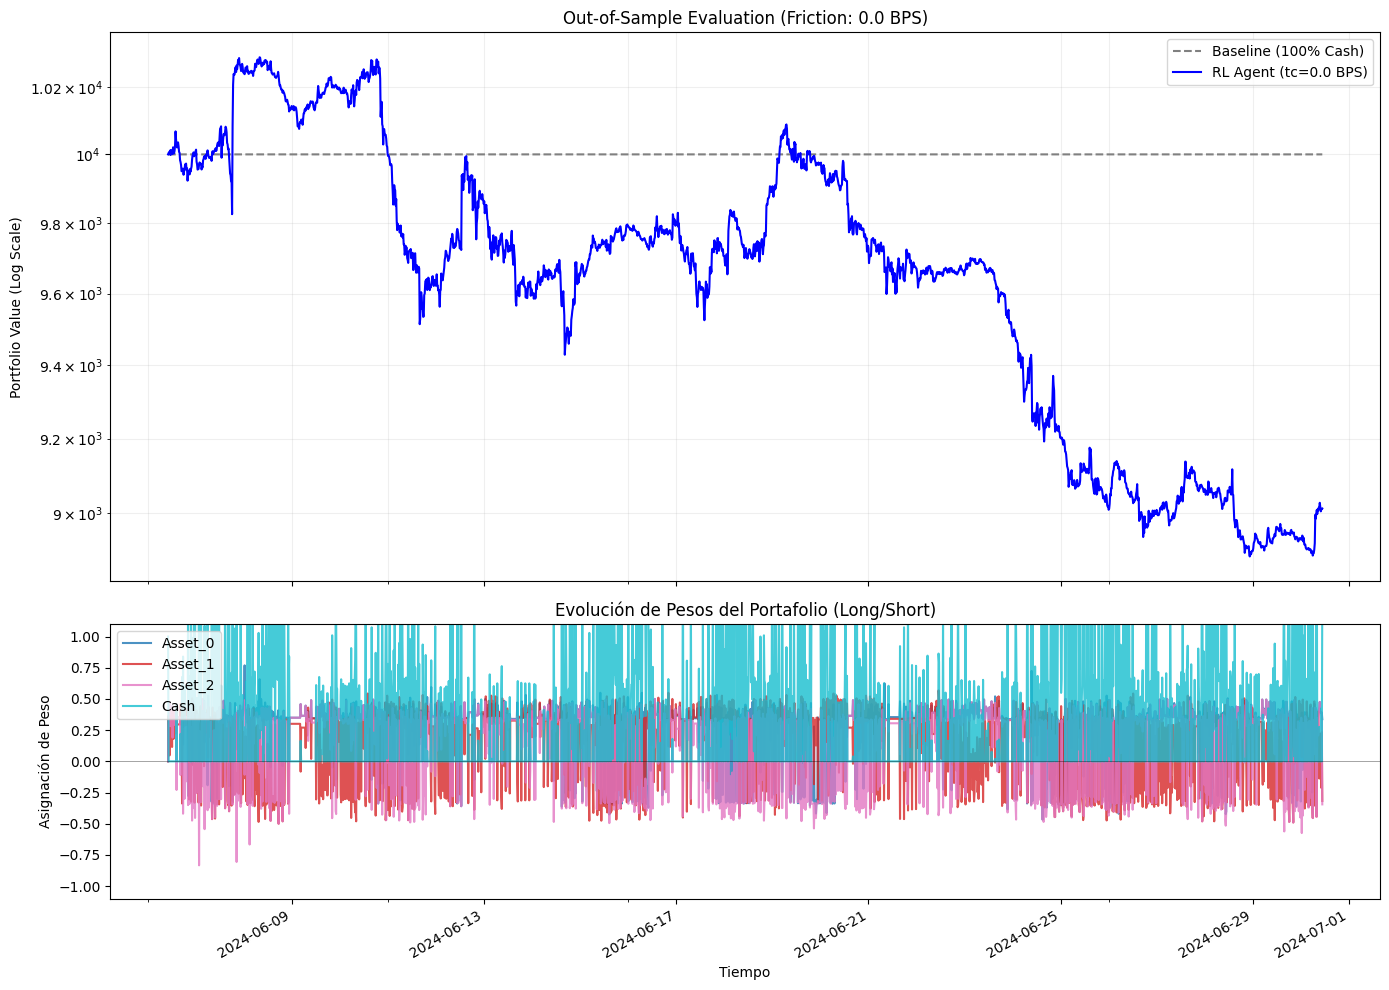


[Exp_2_Drop_410h_171h] Preparando datos...


Test 0.0 BPS: 100%|█████████▉| 2306/2307 [00:12<00:00, 179.04step/s]



📊 RESULTADOS OUT-OF-SAMPLE | Fricción: 0.0 BPS
--------------------------------------------------
Pasos Evaluados:        2308
Valor Final Portafolio: $12,094.43
Retorno Acumulado:      +20.94%


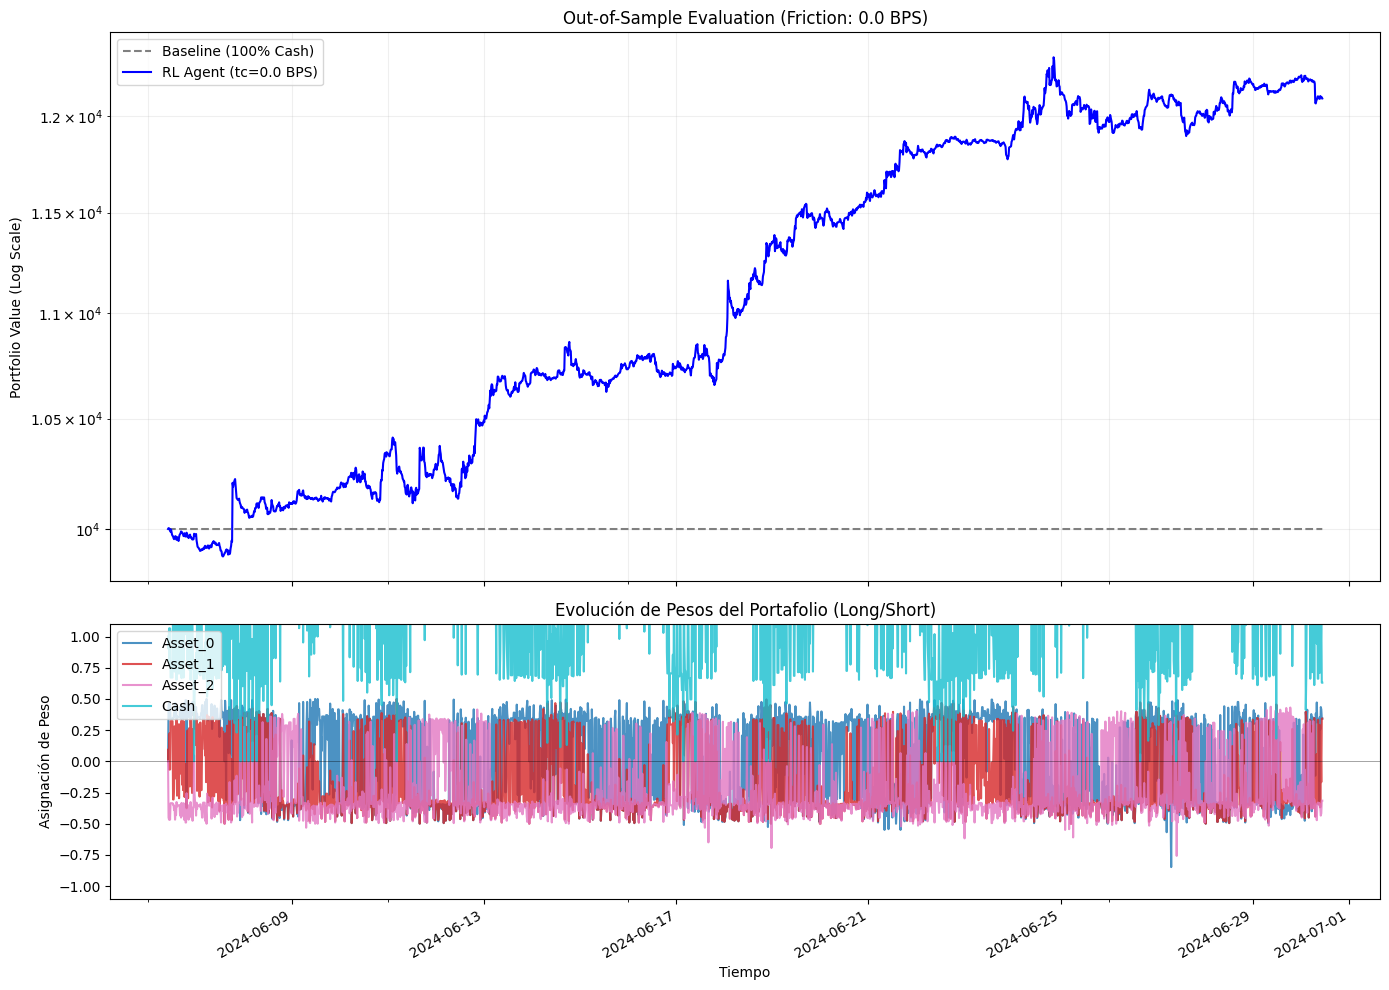


[Exp_3_Micro_Only] Preparando datos...


Test 0.0 BPS: 100%|█████████▉| 2306/2307 [00:13<00:00, 177.08step/s]



📊 RESULTADOS OUT-OF-SAMPLE | Fricción: 0.0 BPS
--------------------------------------------------
Pasos Evaluados:        2308
Valor Final Portafolio: $10,643.51
Retorno Acumulado:      +6.44%


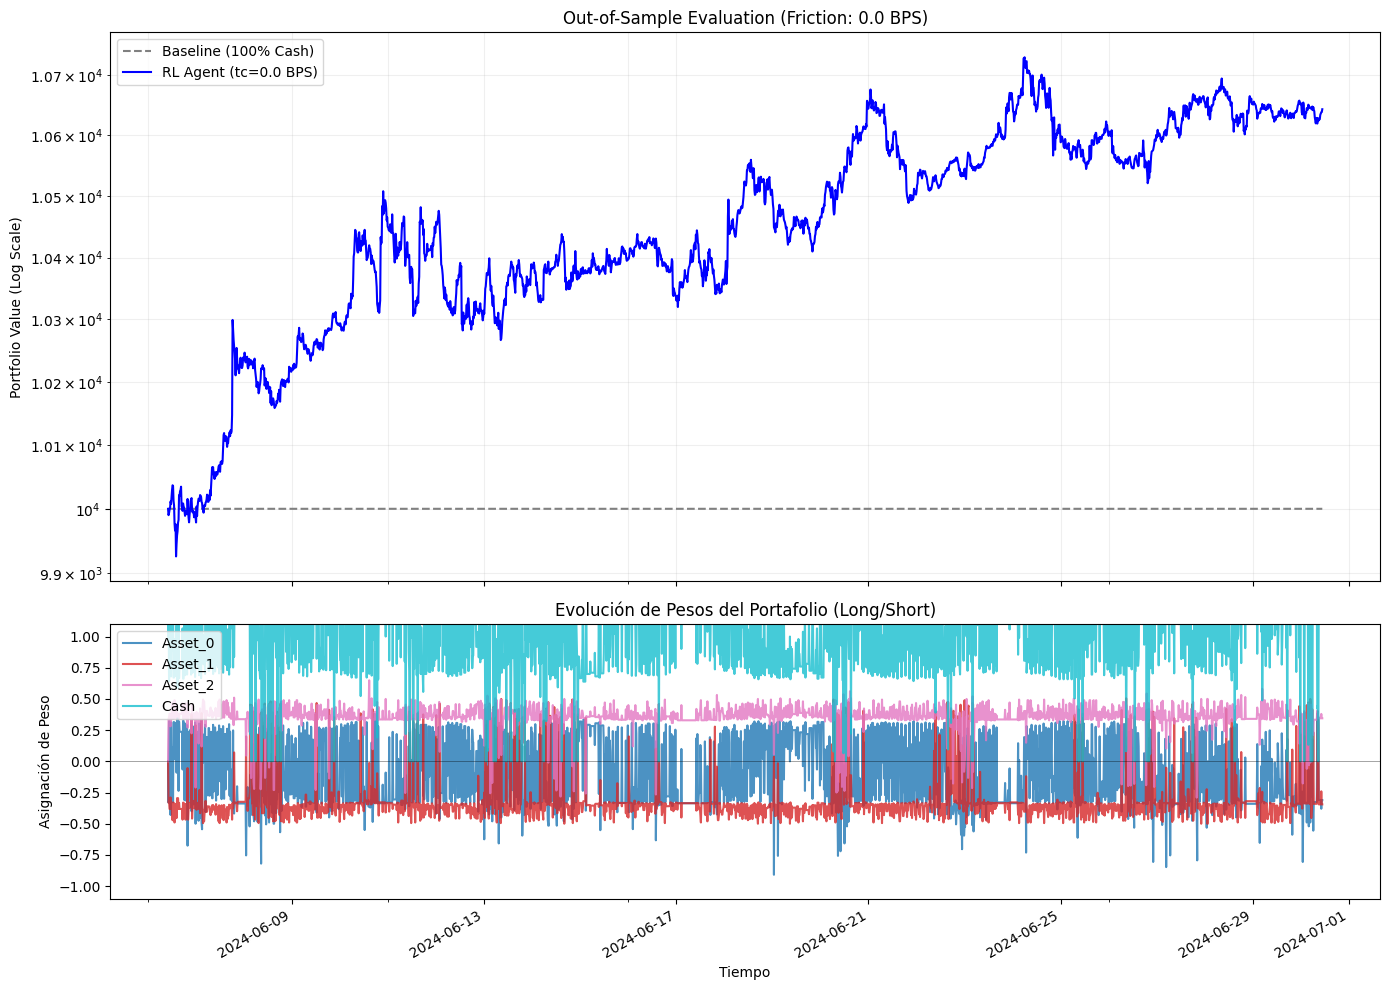


[Exp_4_All_Features] Preparando datos...


Test 0.0 BPS: 100%|█████████▉| 2306/2307 [00:12<00:00, 177.74step/s]



📊 RESULTADOS OUT-OF-SAMPLE | Fricción: 0.0 BPS
--------------------------------------------------
Pasos Evaluados:        2308
Valor Final Portafolio: $9,581.10
Retorno Acumulado:      -4.19%


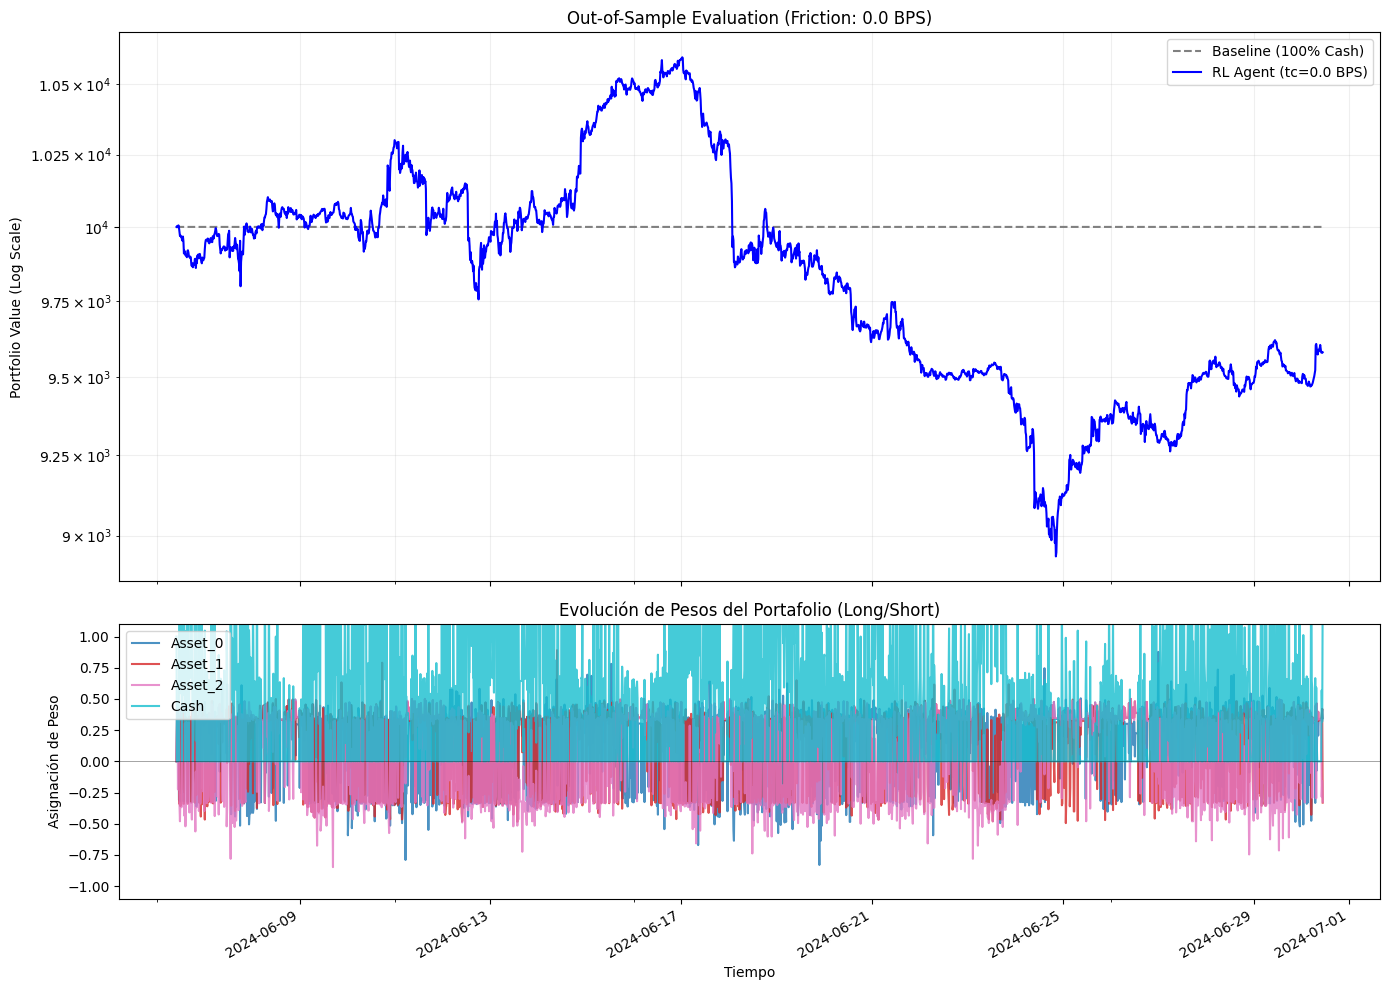


[Exp_5_Hard_Friction_Direct] Preparando datos...


Test 0.0 BPS: 100%|█████████▉| 2306/2307 [00:12<00:00, 179.47step/s]



📊 RESULTADOS OUT-OF-SAMPLE | Fricción: 0.0 BPS
--------------------------------------------------
Pasos Evaluados:        2308
Valor Final Portafolio: $10,737.04
Retorno Acumulado:      +7.37%


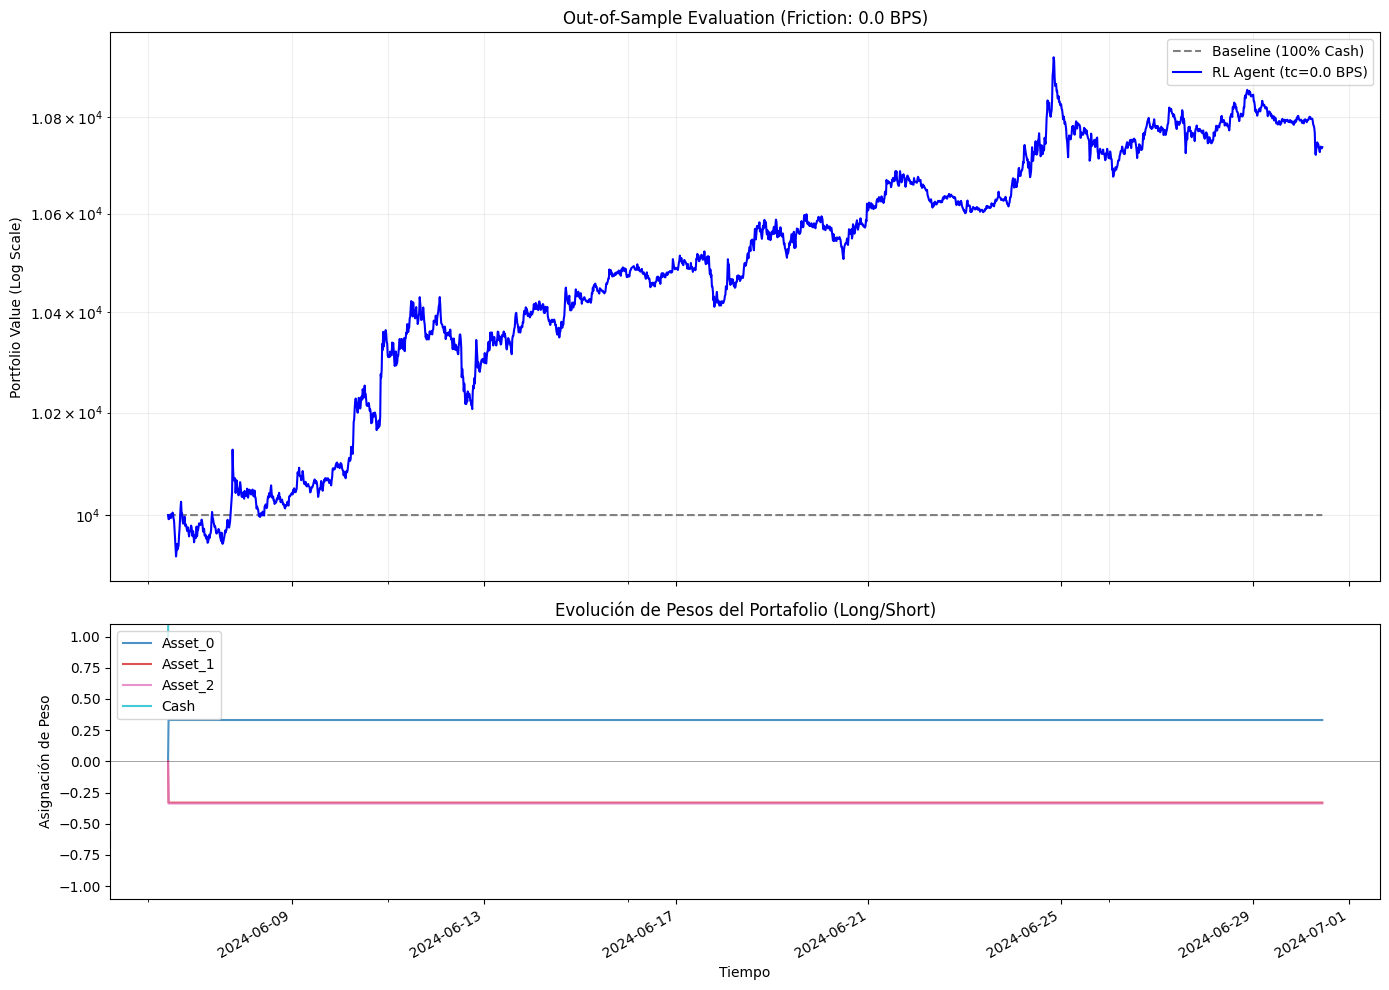


🏆 RANKING FINAL DE RENDIMIENTO (10 BPS)
🥇 1. Exp_2_Drop_410h_171h           |   +20.94%
🥈 2. Exp_5_Hard_Friction_Direct     |    +7.37%
🥉 3. Exp_3_Micro_Only               |    +6.44%
🔸 4. Exp_4_All_Features             |    -4.19%
🔸 5. Exp_1_Drop_410h                |    -9.87%


In [60]:
# ==============================================================================
# BATERÍA DE EVALUACIÓN OUT-OF-SAMPLE (Prueba de Fuego)
# ==============================================================================

def get_filtered_test_data(feat_test_raw: pd.DataFrame, horizons_to_drop: list) -> pd.DataFrame:
    """Filtra el dataset de pruebas para que coincida con la dimensión que espera el agente."""
    if not horizons_to_drop:
        return feat_test_raw.copy()
    cols_to_drop = [c for c in feat_test_raw.columns if any(h in c for h in horizons_to_drop)]
    return feat_test_raw.drop(columns=cols_to_drop)

# 1. Configuración Estricta para todos los agentes (Cancha nivelada)
# Usamos 10 BPS para ver cómo sobreviven en el mundo real.
# Pon max_steps=None si quieres correr toda la historia de test.
eval_config = TestConfig(
    tc_bps=0.0, 
    window_bars=192, 
    max_steps=2500 
)

# 2. Mapeo de los Agentes y sus restricciones de visión
# Formato: (Nombre, Agente_Instanciado, Columnas_A_Podar)
experiments_setup = [
    ("Exp_1_Drop_410h", agent_exp1, ['410h']),
    ("Exp_2_Drop_410h_171h", agent_exp2, ['410h', '171h']),
    ("Exp_3_Micro_Only", agent_exp3, ['410h', '171h', '86h']),
    ("Exp_4_All_Features", agent_exp4, []),
    ("Exp_5_Hard_Friction_Direct", agent_exp5, []) # Asumiendo que usaste todas las variables aquí
]

# Diccionario para guardar los resultados y compararlos después
resultados_finales = {}

print("\n" + "="*70)
print(f"🚀 INICIANDO TORNEO DE AGENTES OUT-OF-SAMPLE | Fricción: {eval_config.tc_bps} BPS")
print("="*70)

# 3. Bucle de Ejecución Dinámica
for exp_name, agent_model, drops in experiments_setup:
    print(f"\n[{exp_name}] Preparando datos...")
    
    # Adaptar la dimensión del dataset al cerebro del agente
    feat_test_adapted = get_filtered_test_data(feat_test, drops)
    
    # Ejecutar la tubería maestra
    resultado = execute_test_pipeline(
        agent=agent_model, 
        feat_df=feat_test_adapted, 
        data_df=data_test, 
        config=eval_config,
        verbose=True,
        plot=True  # Imprime la gráfica de cada uno conforme termina
    )
    
    resultados_finales[exp_name] = resultado.total_return_pct

# ==============================================================================
# TABLA DE POSICIONES FINAL
# ==============================================================================
print("\n" + "="*50)
print("🏆 RANKING FINAL DE RENDIMIENTO (10 BPS)")
print("="*50)
# Ordenar de mayor a menor retorno
ranking = sorted(resultados_finales.items(), key=lambda x: x[1], reverse=True)

for posicion, (nombre, retorno) in enumerate(ranking, 1):
    medalla = "🥇" if posicion == 1 else "🥈" if posicion == 2 else "🥉" if posicion == 3 else "🔸"
    print(f"{medalla} {posicion}. {nombre:<30} | {retorno:>+8.2f}%")
print("="*50)

In [ ]:
# ==============================================================================
# PRUEBA DE SENSIBILIDAD AL ESTADO INICIAL (EXPERIMENTO 5)
# ==============================================================================

print("\n" + "="*70)
print("🧪 TEST DE SENSIBILIDAD AL ESTADO INICIAL | Agente: Exp_5 (10 BPS)")
print("="*70)

# 1. Definimos los Escenarios de Partida
escenarios_iniciales = [
    ("100% Efectivo (Clean Slate)",  (0.0,  0.0,  0.0,  1.0)),
    ("100% Largo Activo 0",          (1.0,  0.0,  0.0,  0.0)),
    ("100% Corto Activo 2",          (0.0,  0.0, -1.0,  1.0)), 
    ("Cobertura (Long A0, Short A1)",(0.5, -0.5,  0.0,  1.0)),
    ("Tu Baseline Original",         (0.0,  1.0, -1.0,  1.0))
]

resultados_sensibilidad = {}
agente_evaluado = agent_exp5 

for nombre, pesos in escenarios_iniciales:
    print(f"\n🔄 Ejecutando: {nombre} | Inicio: {pesos}")
    
    config_escenario = TestConfig(
        tc_bps=10.0, 
        window_bars=PHYSICAL_WINDOW_BARS, 
        max_steps=2000,
        baseline_weights=pesos  
    )
    
    # EJECUCIÓN CORREGIDA: Usamos 'feat_test' (el crudo con las 80 columnas)
    res = execute_test_pipeline(
        agent=agente_evaluado, 
        feat_df=feat_test, # <--- ¡Aquí estaba el error! Pasamos el dataset completo.
        data_df=data_test, 
        config=config_escenario,
        verbose=False, 
        plot=False 
    )
    
    pesos_finales = res.weights_df.iloc[-1].values
    
    resultados_sensibilidad[nombre] = {
        'Retorno': res.total_return_pct,
        'Pesos_Fin': pesos_finales
    }

# ==============================================================================
# REPORTE DE CONVERGENCIA
# ==============================================================================
print("\n" + "="*80)
print(f"{'ESCENARIO INICIAL':<30} | {'RETORNO':<8} | {'PORTAFOLIO FINAL [A0, A1, A2, CASH]':<35}")
print("-" * 80)

for nombre, datos in resultados_sensibilidad.items():
    ret = datos['Retorno']
    p_fin = [f"{w:+.2f}" for w in datos['Pesos_Fin']]
    p_fin_str = f"[{', '.join(p_fin)}]"
    
    print(f"{nombre:<30} | {ret:>+7.2f}% | {p_fin_str:<35}")
print("="*80)


🧪 TEST DE SENSIBILIDAD AL ESTADO INICIAL | Agente: Exp_5 (10 BPS)

🔄 Ejecutando: 100% Efectivo (Clean Slate) | Inicio: (0.0, 0.0, 0.0, 1.0)

🔄 Ejecutando: 100% Largo Activo 0 | Inicio: (1.0, 0.0, 0.0, 0.0)

🔄 Ejecutando: 100% Corto Activo 2 | Inicio: (0.0, 0.0, -1.0, 1.0)

🔄 Ejecutando: Cobertura (Long A0, Short A1) | Inicio: (0.5, -0.5, 0.0, 1.0)

🔄 Ejecutando: Tu Baseline Original | Inicio: (0.0, 1.0, -1.0, 1.0)

ESCENARIO INICIAL              | RETORNO  | PORTAFOLIO FINAL [A0, A1, A2, CASH]
--------------------------------------------------------------------------------
100% Efectivo (Clean Slate)    |   +7.79% | [+0.33, -0.33, -0.34, +1.34]       
100% Largo Activo 0            |   +7.79% | [+0.33, -0.33, -0.34, +1.34]       
100% Corto Activo 2            |   +7.79% | [+0.33, -0.33, -0.34, +1.34]       
Cobertura (Long A0, Short A1)  |   +7.79% | [+0.33, -0.33, -0.34, +1.34]       
Tu Baseline Original           |   +7.79% | [+0.33, -0.33, -0.34, +1.34]       


In [69]:
import torch
from pathlib import Path

# ==============================================================================
# PRUEBA DE SENSIBILIDAD | PACIENTE CERO (quantroberta_phase_1_aprendio_buy_and_hold.pth)
# ==============================================================================

print("\n" + "="*70)
print("🧪 TEST DE SENSIBILIDAD AL ESTADO INICIAL | Agente: MODELO ANTIGUO")
print("="*70)

# 1. Cargar el "Cerebro" Antiguo
# Usamos input_features_dim = feat_test.shape[1] - 3 asumiendo que tiene las 80 columnas
dynamic_input_dim_old = feat_test.shape[1] - 3 

backbone_viejo = QuantRobertaBody(
    input_features_dim=dynamic_input_dim_old, 
    time_features_dim=3,
    d_model=256,
    raw_window_bars=PHYSICAL_WINDOW_BARS, 
    patch_size=PATCH_SIZE,                
    stride=STRIDE                         
)
agent_viejo = QuantTradingAgent(backbone=backbone_viejo)

# Ruta absoluta que proporcionaste
modelo_path = Path(r"C:\Users\ddfa9\Proyectos\bellmancapital\notebooks\experiments\Exp_4_All\quantroberta_phase_1.pth")#Path(r"C:\Users\ddfa9\Proyectos\bellmancapital\notebooks\quantroberta_phase_1_aprendio_buy_and_hold.pth")

print(f"🧠 Cargando pesos neuronales desde: {modelo_path.name}...")
agent_viejo.load_state_dict(torch.load(modelo_path))
agent_viejo.eval() # Fijar la red en modo inferencia

# 2. Definimos los Escenarios de Partida
escenarios_iniciales = [
    ("100% Efectivo (Clean Slate)",  (0.0,  0.0,  0.0,  1.0)),
    ("100% Largo Activo 0",          (1.0,  0.0,  0.0,  0.0)),
    ("100% Corto Activo 2",          (0.0,  0.0, -1.0,  1.0)), 
    ("Cobertura (Long A0, Short A1)",(-0.33, 0.33,  -.33,  1.33)),
    ("Tu Baseline Original",         (0.0,  1.0, -1.0,  1.0))
]

resultados_sensibilidad_viejo = {}

for nombre, pesos in escenarios_iniciales:
    print(f"\n🔄 Ejecutando: {nombre} | Inicio: {pesos}")
    
    config_escenario = TestConfig(
        tc_bps=1.0, # Ajustado a 1.0 como pediste
        window_bars=PHYSICAL_WINDOW_BARS, 
        max_steps=2000, # Reducido a 2000 para esta prueba
        baseline_weights=pesos  
    )
    
    res = execute_test_pipeline(
        agent=agent_viejo, 
        feat_df=feat_test, # Dataset crudo con todas las variables
        data_df=data_test, 
        config=config_escenario,
        verbose=False, 
        plot=False 
    )
    
    pesos_finales = res.weights_df.iloc[-1].values
    
    resultados_sensibilidad_viejo[nombre] = {
        'Retorno': res.total_return_pct,
        'Pesos_Fin': pesos_finales
    }

# ==============================================================================
# REPORTE DE CONVERGENCIA (MODELO ANTIGUO)
# ==============================================================================
print("\n" + "="*80)
print(f"{'ESCENARIO INICIAL':<30} | {'RETORNO':<8} | {'PORTAFOLIO FINAL [A0, A1, A2, CASH]':<35}")
print("-" * 80)

for nombre, datos in resultados_sensibilidad_viejo.items():
    ret = datos['Retorno']
    p_fin = [f"{w:+.2f}" for w in datos['Pesos_Fin']]
    p_fin_str = f"[{', '.join(p_fin)}]"
    
    print(f"{nombre:<30} | {ret:>+7.2f}% | {p_fin_str:<35}")
print("="*80)


🧪 TEST DE SENSIBILIDAD AL ESTADO INICIAL | Agente: MODELO ANTIGUO
🧠 Cargando pesos neuronales desde: quantroberta_phase_1.pth...

🔄 Ejecutando: 100% Efectivo (Clean Slate) | Inicio: (0.0, 0.0, 0.0, 1.0)

🔄 Ejecutando: 100% Largo Activo 0 | Inicio: (1.0, 0.0, 0.0, 0.0)

🔄 Ejecutando: 100% Corto Activo 2 | Inicio: (0.0, 0.0, -1.0, 1.0)

🔄 Ejecutando: Cobertura (Long A0, Short A1) | Inicio: (-0.33, 0.33, -0.33, 1.33)

🔄 Ejecutando: Tu Baseline Original | Inicio: (0.0, 1.0, -1.0, 1.0)

ESCENARIO INICIAL              | RETORNO  | PORTAFOLIO FINAL [A0, A1, A2, CASH]
--------------------------------------------------------------------------------
100% Efectivo (Clean Slate)    |  -15.26% | [+0.48, +0.36, -0.16, +0.33]       
100% Largo Activo 0            |  -15.26% | [+0.48, +0.36, -0.16, +0.33]       
100% Corto Activo 2            |  -15.26% | [+0.48, +0.36, -0.16, +0.33]       
Cobertura (Long A0, Short A1)  |  -15.26% | [+0.48, +0.36, -0.16, +0.33]       
Tu Baseline Original           


🧪 TEST DE HISTORIA COMPLETA | Agente: Exp_5 (10 BPS) | Baseline Original


Test 10.0 BPS: 100%|█████████▉| 54968/54969 [06:28<00:00, 141.42step/s]



📊 RESULTADOS OUT-OF-SAMPLE | Fricción: 10.0 BPS
--------------------------------------------------
Pasos Evaluados:        54970
Valor Final Portafolio: $7,243.91
Retorno Acumulado:      -27.56%


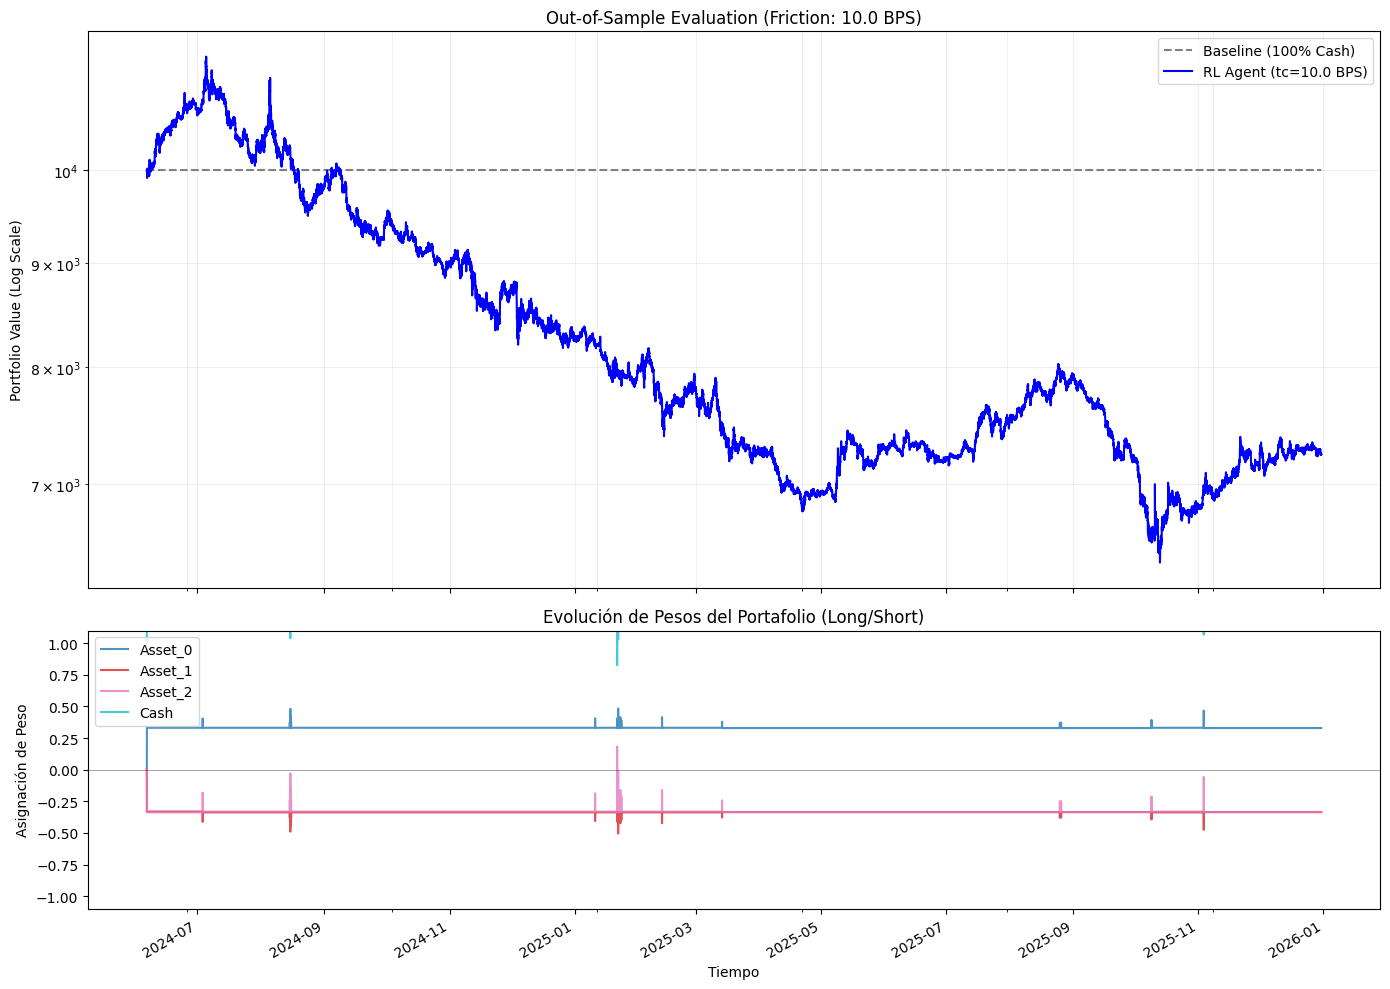


--------------------------------------------------
📌 Distribución Final del Portafolio: [+0.33, -0.34, -0.34, +1.34]
--------------------------------------------------


In [ ]:
# ==============================================================================
# PRUEBA OUT-OF-SAMPLE | DATASET COMPLETO (Exp_5 a 10 BPS)
# ==============================================================================

print("\n" + "="*80)
print("🧪 TEST DE HISTORIA COMPLETA | Agente: Exp_5 (10 BPS) | Baseline Original")
print("="*80)

# 1. Configuración de la prueba: max_steps=None para consumir todo el dataset
config_full = TestConfig(
    tc_bps=10.0, 
    window_bars=PHYSICAL_WINDOW_BARS, 
    max_steps=None, # <--- Sin límite, corre toda la historia
    baseline_weights=(0.0, 0.0, 0.0, 1.0) # Tu baseline original
)

# 2. Ejecutar la tubería maestra
# Se pasa 'feat_test' completo porque el Exp_5 usa las 80 columnas
res_full = execute_test_pipeline(
    agent=agent_exp5, 
    feat_df=feat_test, 
    data_df=data_test, 
    config=config_full,
    verbose=True, 
    plot=True 
)

# 3. Mostrar la composición del portafolio final
pesos_finales = res_full.weights_df.iloc[-1].values
p_fin_str = f"[{', '.join([f'{w:+.2f}' for w in pesos_finales])}]"

print("\n" + "-"*50)
print(f"📌 Distribución Final del Portafolio: {p_fin_str}")
print("-"*50)


⚙️ Alineando y cortando datasets para prueba rápida...
✅ Datasets alineados. Evaluando 5000 velas (Desde 2024-06-04 09:59:59.999000 hasta 2024-07-26 11:44:59.999000).

--- RUN 1: TESTING PURE PREDICTIVE ALPHA (0 BPS) ---

🔬 Initiating Out-of-Sample Evaluation (Friction: 0.0 BPS)...
🤖 Ejecutando forward pass secuencial para 4807 pasos...


Test 0.0 BPS:   0%|          | 0/4807 [00:00<?, ?step/s]

Test 0.0 BPS: 100%|██████████| 4807/4807 [00:28<00:00, 168.04step/s]


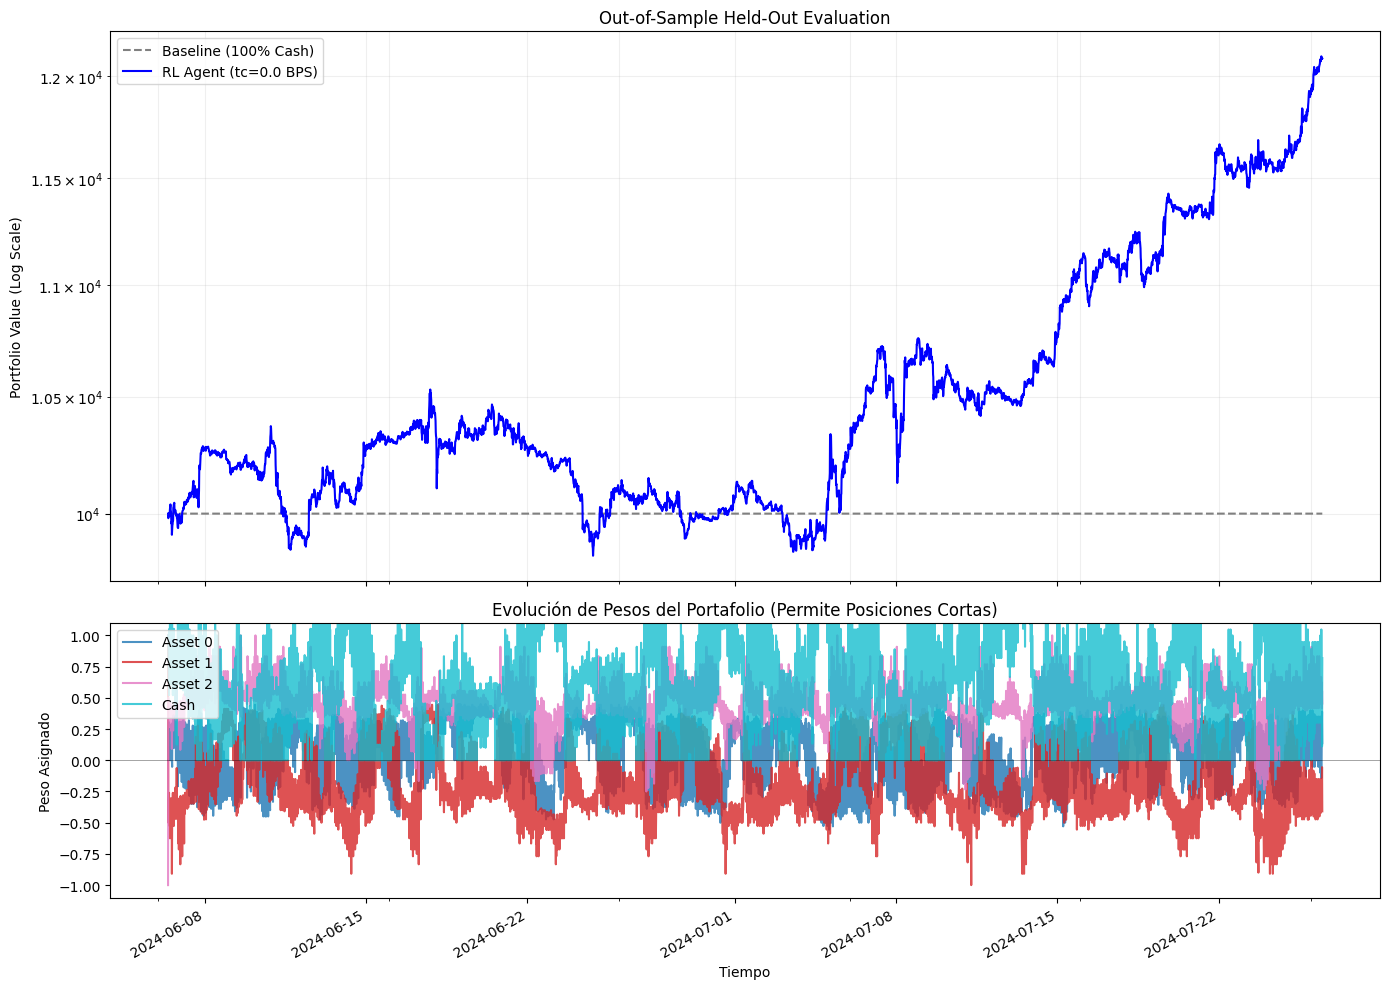

📊 TEST EVALUATION RESULTS
--------------------------------------------------
Total Steps Evaluated: 4808
Final Portfolio Value: $12089.99
Cumulative Return:     +20.90%

--- RUN 2: TESTING REAL WORLD FRICTION (10 BPS) ---

🔬 Initiating Out-of-Sample Evaluation (Friction: 10.0 BPS)...
🤖 Ejecutando forward pass secuencial para 4807 pasos...


Test 10.0 BPS:  41%|████      | 1961/4807 [00:12<00:18, 157.68step/s]


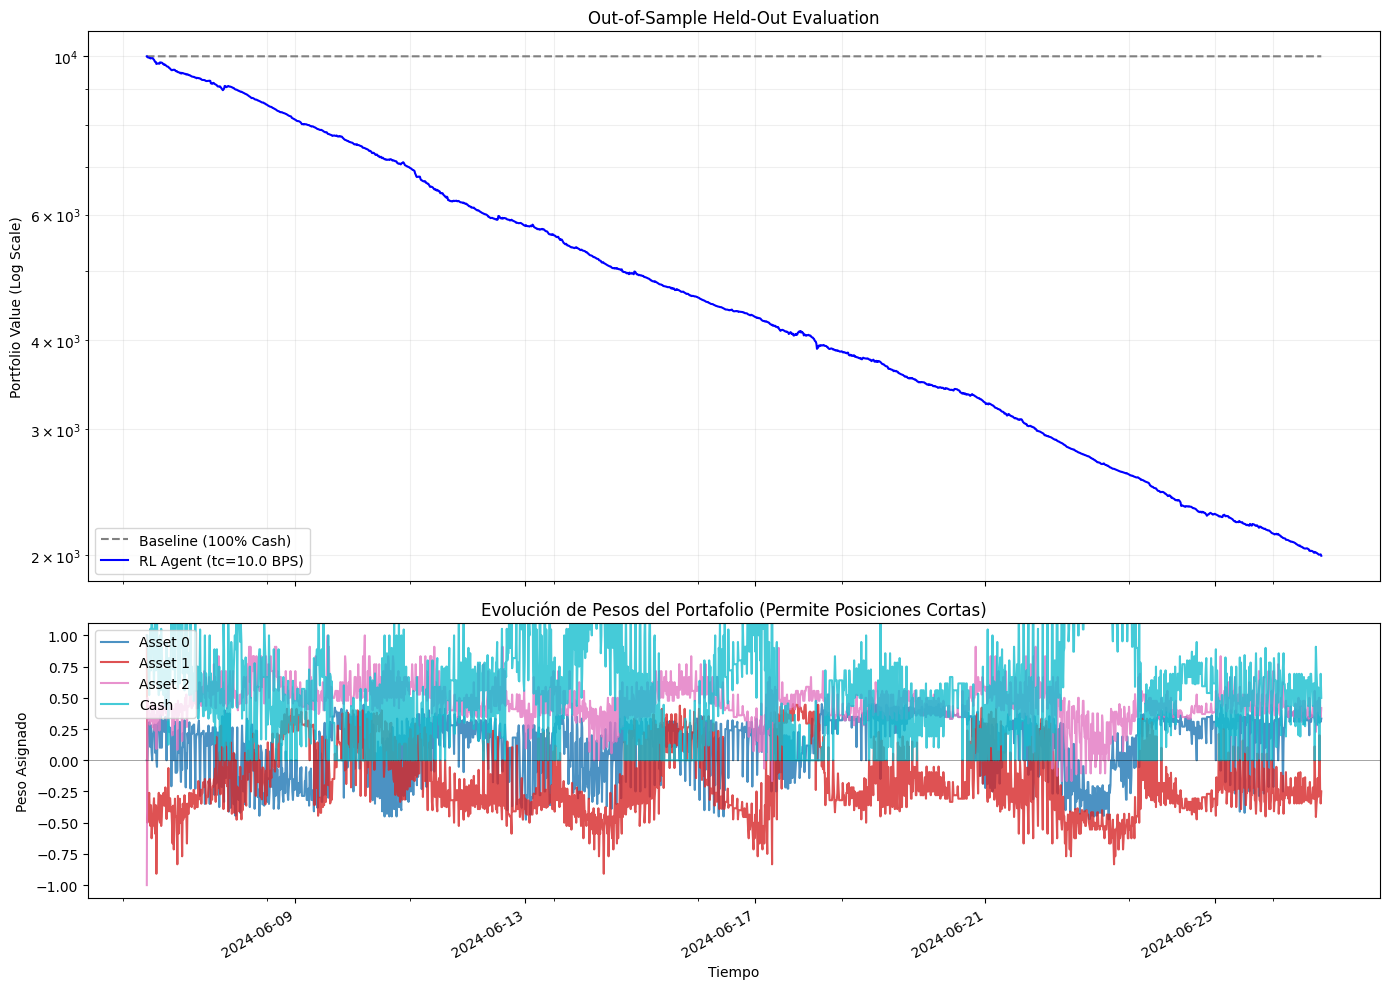

📊 TEST EVALUATION RESULTS
--------------------------------------------------
Total Steps Evaluated: 1962
Final Portfolio Value: $1996.21
Cumulative Return:     -80.04%


In [ ]:
'''import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==============================================================================
# OUT-OF-SAMPLE EVALUATION FUNCTION
# ==============================================================================
def run_out_of_sample_test(agent, feat_test, data_test, tc_bps=10.0, window_bars=192):
    print(f"\n🔬 Initiating Out-of-Sample Evaluation (Friction: {tc_bps} BPS)...")
    
    device = next(agent.parameters()).device
    prices_test_np = data_test[['asset_0_close', 'asset_1_close', 'asset_2_close']].values
    
    test_env = TransformerTradingEnv(
        features_df=feat_test, 
        close_prices=prices_test_np, 
        max_window=window_bars, 
        tc_bps=tc_bps,
        episode_length=2048 
    )
    
    obs, _ = test_env.reset()
    
    # ====================================================================
    # 🚀 HIJACK THE ENVIRONMENT FOR DETERMINISTIC WALK-FORWARD
    # ====================================================================
    start_idx = test_env.max_window 
    test_env._t = start_idx
    
    test_env._end_step = len(data_test) - 1
    test_env.episode_length = len(data_test)
    
    test_env._weights = np.array([0.0, 1.0, -1.0, 1.0], dtype=np.float32) 
    test_env._value = 10000.0                   
    
    obs = test_env._get_obs()                       
    # ====================================================================
    
    
    
    # 4. Tracking Variables
    done = False
    portfolio_history = [test_env._value]
    # --- NUEVO: Rastrear pesos ---
    weights_history = [test_env._weights.copy()] 
    
    agent.eval()
    
    total_steps = test_env._end_step - start_idx
    print(f"🤖 Ejecutando forward pass secuencial para {total_steps} pasos...")
    
    with torch.no_grad():
        with tqdm(total=total_steps, desc=f"Test {tc_bps} BPS", unit="step") as pbar:
            while not done:
                if obs['x'].shape[0] != window_bars:
                    break

                obs_tensor = {k: torch.tensor(v, dtype=torch.float32, device=device).unsqueeze(0) for k, v in obs.items()}
                
                latent_features = agent.encoder(
                    x=obs_tensor['x'], 
                    t=obs_tensor['t'], 
                    portfolio_weights=obs_tensor['portfolio'], 
                    bars_since_trade=obs_tensor['inertia'], 
                    raw_padding_mask=obs_tensor['mask']
                )
                action_dist = agent.actor(latent_features) 
                action = action_dist.mean.cpu().numpy()[0]
                
                obs, reward, terminated, truncated, info = test_env.step(action)
                done = terminated or truncated
                
                portfolio_history.append(test_env._value)
                # --- NUEVO: Guardar pesos del paso actual ---
                weights_history.append(test_env._weights.copy())
                pbar.update(1)

    # 6. Alinear índices
    actual_steps = len(portfolio_history)
    valid_index = data_test.index[start_idx : start_idx + actual_steps]
    
    curve = pd.Series(portfolio_history, index=valid_index)
    cash_baseline = pd.Series(10000.0, index=valid_index)
    
    # --- NUEVO: DataFrame de pesos ---
    weights_df = pd.DataFrame(weights_history, index=valid_index, columns=['Asset 0', 'Asset 1', 'Asset 2', 'Cash'])
    
    # 8. Plot the Results (Rendimiento)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
    
    ax1.plot(cash_baseline, label='Baseline (100% Cash)', color='gray', linestyle='--')
    ax1.plot(curve, label=f'RL Agent (tc={tc_bps} BPS)', color='blue', linewidth=1.5)
    ax1.set_yscale('log')
    ax1.set_title("Out-of-Sample Held-Out Evaluation")
    ax1.set_ylabel("Portfolio Value (Log Scale)")
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.2)
    
    # --- PLOT DEL PORTAFOLIO CORREGIDO (LONG/SHORT) ---
    # Usamos un gráfico de líneas regular en lugar de área apilada
    weights_df.plot.line(ax=ax2, cmap='tab10', alpha=0.8, linewidth=1.5)
    
    # Dibujar una línea cero para distinguir posiciones largas de cortas
    ax2.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    
    ax2.set_title("Evolución de Pesos del Portafolio (Permite Posiciones Cortas)")
    ax2.set_ylabel("Peso Asignado")
    ax2.set_xlabel("Tiempo")
    ax2.set_ylim(-1.1, 1.1) # Expandir para acomodar el rango completo [-1.0, 1.0]
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # 9. Print Metrics
    total_ret = (curve.iloc[-1] / curve.iloc[0] - 1) * 100
    print("=" * 50)
    print("📊 TEST EVALUATION RESULTS")
    print("-" * 50)
    print(f"Total Steps Evaluated: {len(curve)}")
    print(f"Final Portfolio Value: ${curve.iloc[-1]:.2f}")
    print(f"Cumulative Return:     {total_ret:+.2f}%")
    print("=" * 50)
    
    return curve


# ==============================================================================
# EXECUTION
# ==============================================================================
"""
print("\n--- RUN 1: TESTING PURE PREDICTIVE ALPHA ---")
test_curve_0bps = run_out_of_sample_test(
    agent=master_agent, 
    feat_test=feat_test, 
    data_test=data_test, 
    tc_bps=0.0,            
    window_bars=PHYSICAL_WINDOW_BARS
)

print("\n--- RUN 2: TESTING REAL WORLD FRICTION ---")
test_curve_10bps = run_out_of_sample_test(
    agent=master_agent, 
    feat_test=feat_test, 
    data_test=data_test, 
    tc_bps=10.0,           
    window_bars=PHYSICAL_WINDOW_BARS
)"""


# ==============================================================================
# EXECUTION (ALINEADO Y OPTIMIZADO PARA PRUEBA RÁPIDA)
# ==============================================================================

print("\n⚙️ Alineando y cortando datasets para prueba rápida...")

# 1. Intersectar los índices para garantizar alineación temporal perfecta
common_index = feat_test_filtered.index.intersection(data_test.index)

# 2. Tomar solo una pequeña porción (ej. 5,000 pasos = ~52 días si son velas de 15m)
TEST_STEPS = 5000
subset_index = common_index[:TEST_STEPS]

feat_test_fast = feat_test_filtered.loc[subset_index].copy()
data_test_fast = data_test.loc[subset_index].copy()

print(f"✅ Datasets alineados. Evaluando {len(subset_index)} velas (Desde {subset_index[0]} hasta {subset_index[-1]}).")

# 3. Ejecutar los tests en la porción rápida
print("\n--- RUN 1: TESTING PURE PREDICTIVE ALPHA (0 BPS) ---")
test_curve_0bps = run_out_of_sample_test(
    agent=master_agent, 
    feat_test=feat_test_fast, 
    data_test=data_test_fast, 
    tc_bps=0.0,            
    window_bars=PHYSICAL_WINDOW_BARS
)

print("\n--- RUN 2: TESTING REAL WORLD FRICTION (10 BPS) ---")
test_curve_10bps = run_out_of_sample_test(
    agent=master_agent, 
    feat_test=feat_test_fast, 
    data_test=data_test_fast, 
    tc_bps=10.0,           
    window_bars=PHYSICAL_WINDOW_BARS
)'''

In [33]:
feat_train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 223105 entries, 2018-01-09 14:29:59.999000 to 2024-05-26 20:44:59.999000
Data columns (total 83 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time_min                223105 non-null  float64
 1   time_hour               223105 non-null  float64
 2   time_dow                223105 non-null  float64
 3   spread_1_0_base         223105 non-null  float64
 4   spread_2_0_base         223105 non-null  float64
 5   spread_1_0_86h          223105 non-null  float64
 6   spread_2_0_86h          223105 non-null  float64
 7   spread_1_0_171h         223105 non-null  float64
 8   spread_2_0_171h         223105 non-null  float64
 9   spread_1_0_410h         223105 non-null  float64
 10  spread_2_0_410h         223105 non-null  float64
 11  asset_0_raw_log_ret     223105 non-null  float64
 12  asset_0_raw_abs_ret     223105 non-null  float64
 13  asset_0_raw_amplitude   223105 non-nu


🧪 TEST DE SENSIBILIDAD AL ESTADO INICIAL | Agente: MODELO ANTIGUO (Fase 1)
🧠 Cargando pesos neuronales desde: quantroberta_phase_1.pth...


🔄 Preparando escenario: 100% Efectivo (Clean Slate)


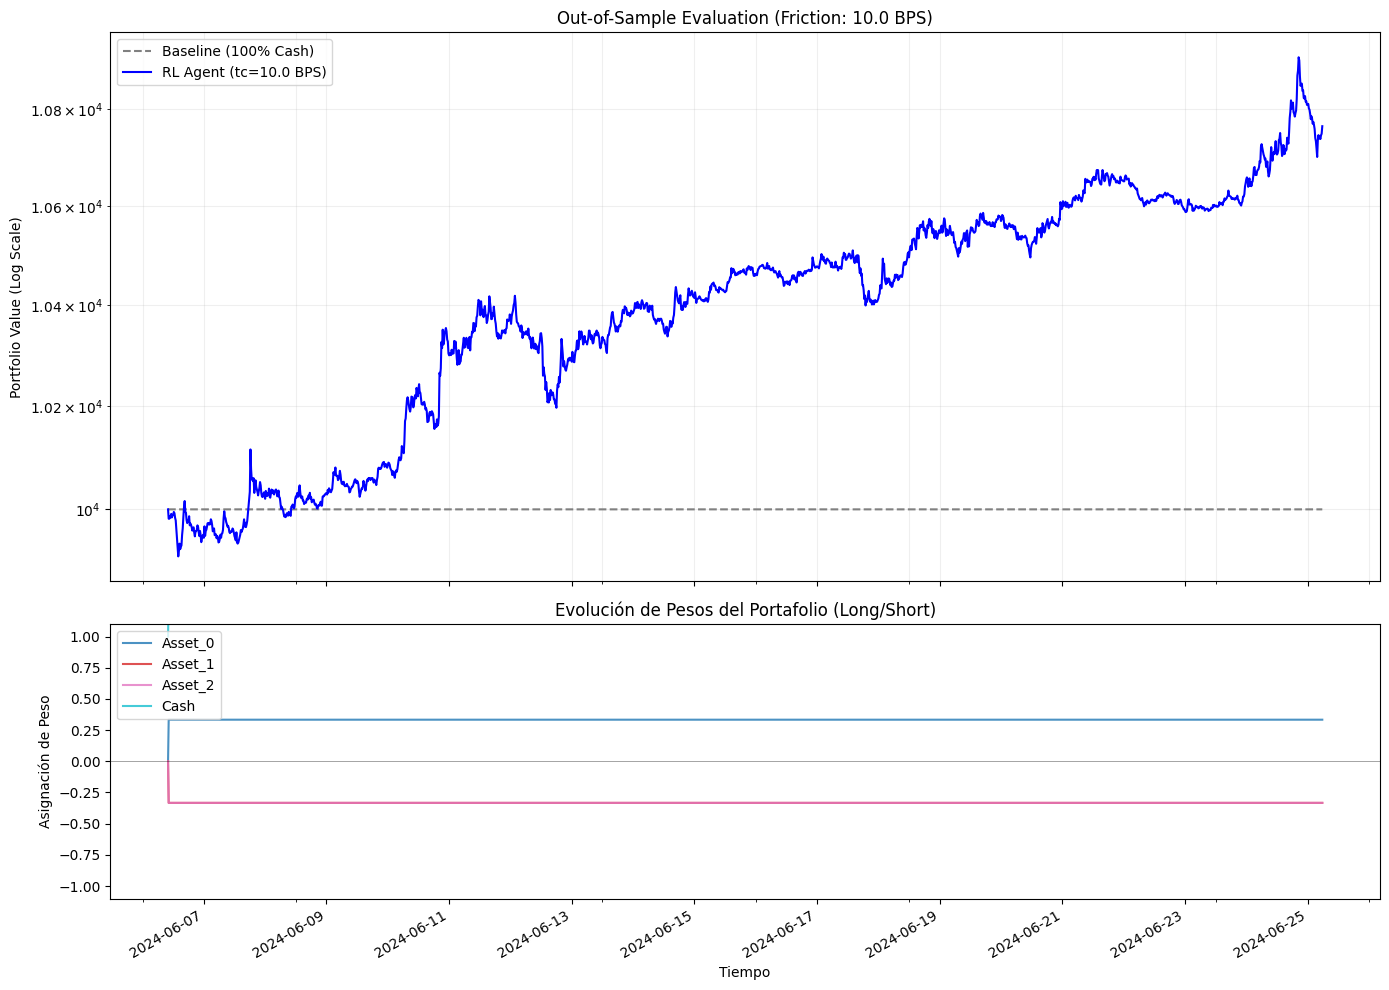


🔄 Preparando escenario: 100% Largo Activo 0


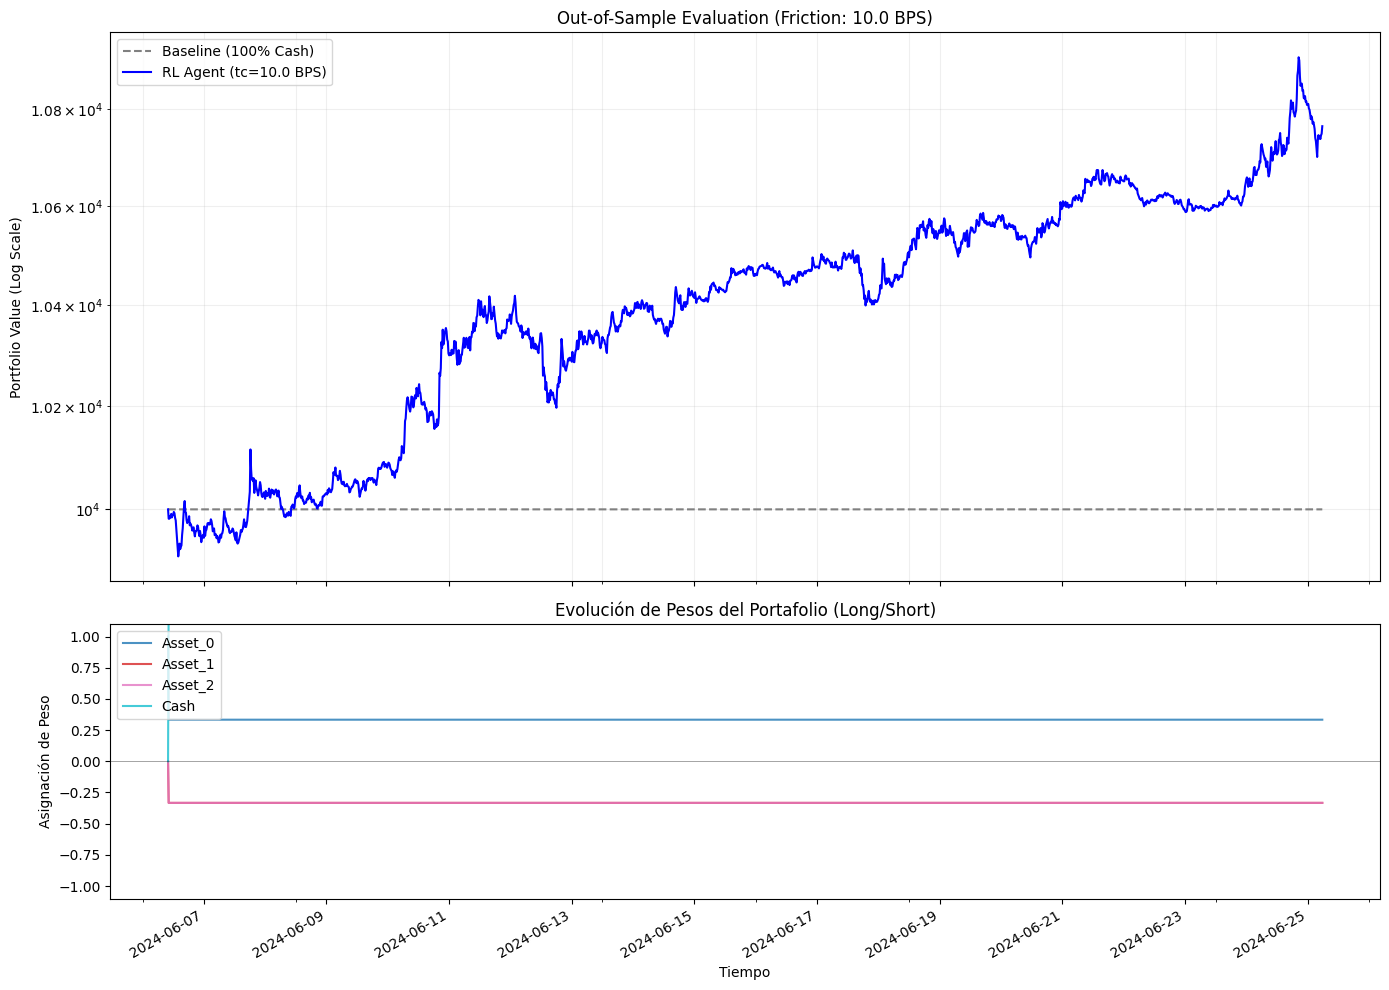


🔄 Preparando escenario: 100% Corto Activo 2


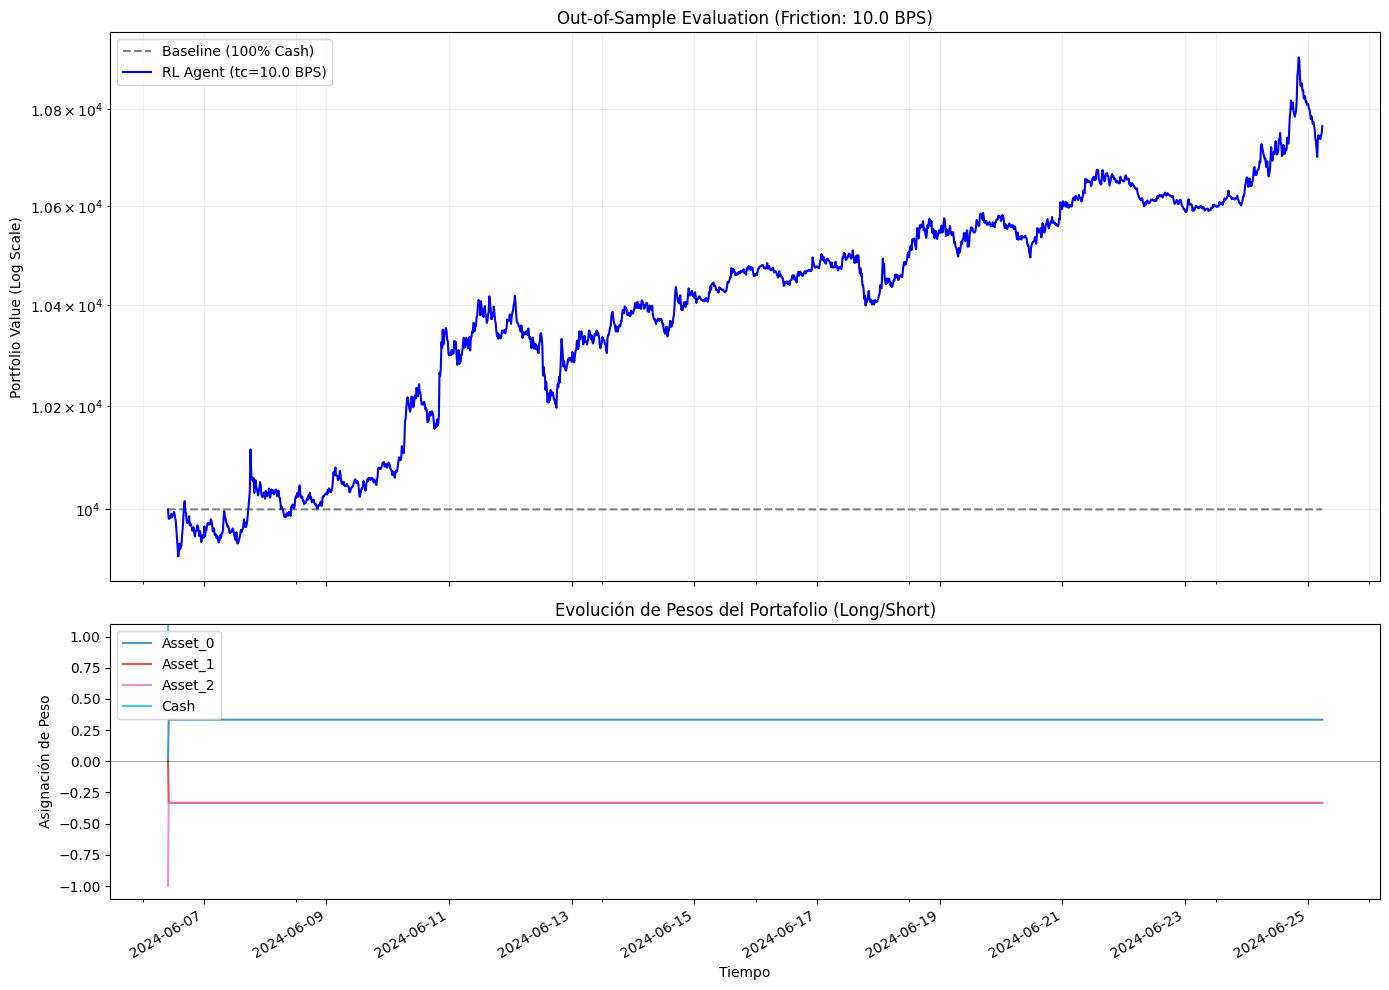


🔄 Preparando escenario: Cobertura (Long A0, Short A1)


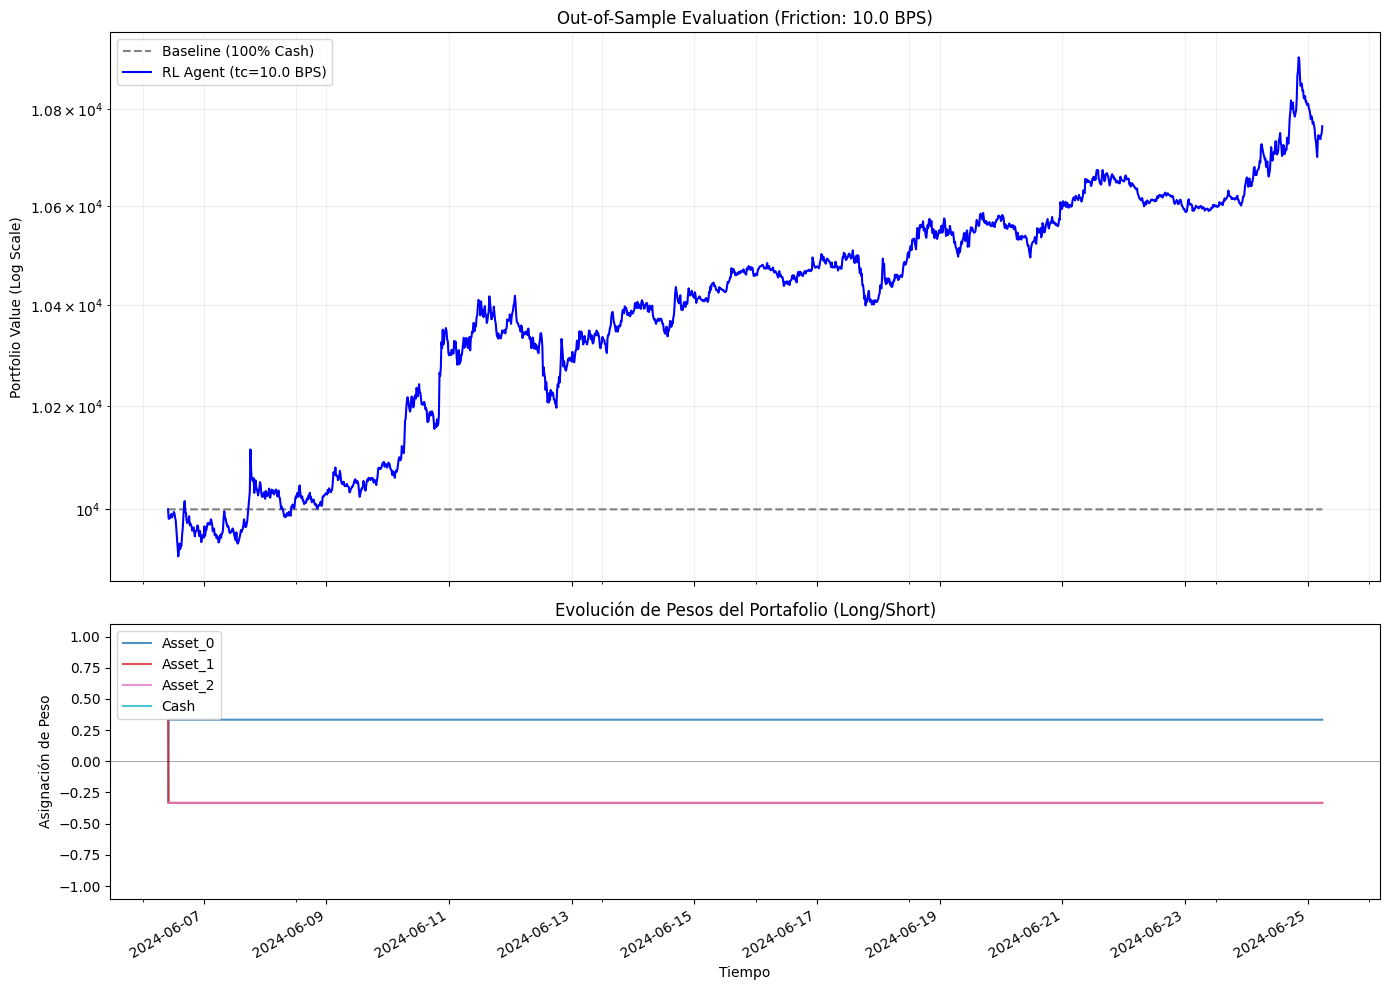


🔄 Preparando escenario: Tu Baseline Original


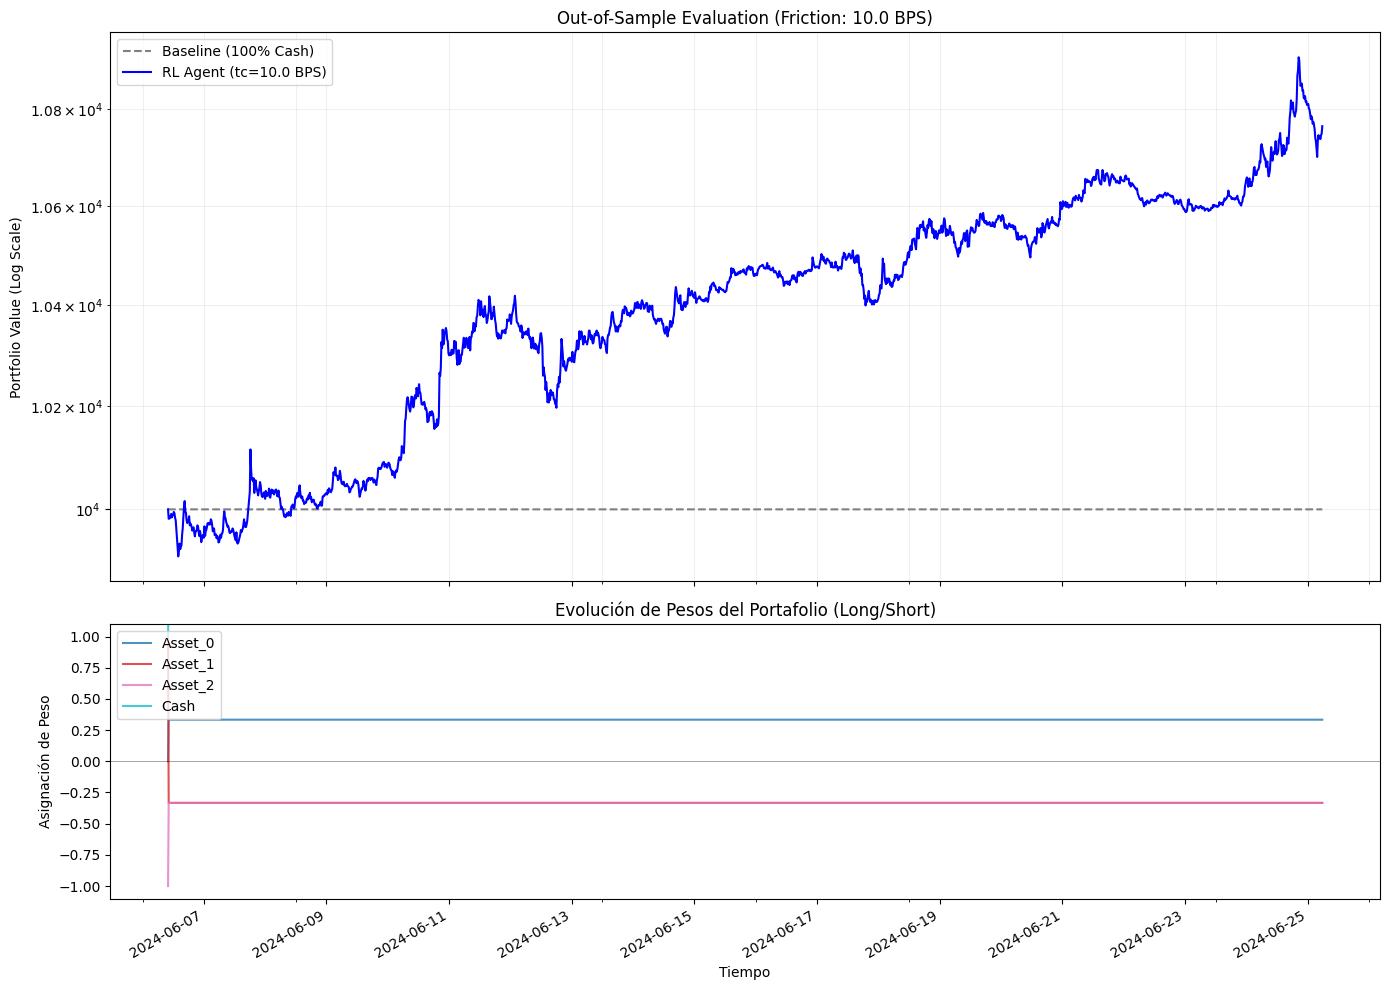


ESCENARIO INICIAL              | RETORNO  | WIN RATE | SORTINO  | MAX DD   | FEES PAGADOS | PESOS FINALES                 
------------------------------------------------------------------------------------------------------------------------
100% Efectivo (Clean Slate)    |   +7.64% |   50.69% |   11.26 |    2.13% | $     13.33 | [+0.33, -0.33, -0.33, +1.33]  
100% Largo Activo 0            |   +7.64% |   50.69% |   11.26 |    2.13% | $     26.67 | [+0.33, -0.33, -0.33, +1.33]  
100% Corto Activo 2            |   +7.64% |   50.69% |   11.26 |    2.13% | $     16.67 | [+0.33, -0.33, -0.33, +1.33]  
Cobertura (Long A0, Short A1)  |   +7.64% |   50.69% |   11.26 |    2.13% | $     13.33 | [+0.33, -0.33, -0.33, +1.33]  
Tu Baseline Original           |   +7.64% |   50.69% |   11.26 |    2.13% | $     26.67 | [+0.33, -0.33, -0.33, +1.33]  


In [84]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from dataclasses import dataclass

# ==============================================================================
# 1. CONTRATOS PARA LAS MÉTRICAS DE LA RÚBRICA
# ==============================================================================
@dataclass(frozen=True)
class RubricMetrics:
    cumulative_return_pct: float
    max_drawdown_pct: float
    sortino_ratio: float
    total_fees_paid: float
    win_rate_pct: float

# ==============================================================================
# 2. FUNCIÓN PURA: CÁLCULO DE MÉTRICAS INSTITUCIONALES
# ==============================================================================
def calculate_rubric_metrics(result: TestResult, periods_per_year: int = 24192) -> RubricMetrics:
    """[PURA] Extrae métricas de riesgo y costos a partir de la curva de capital inmutable."""
    
    # A. Max Drawdown
    roll_max = result.portfolio_curve.cummax()
    drawdown = (result.portfolio_curve - roll_max) / roll_max
    max_dd = abs(drawdown.min()) * 100.0
    
    # B. Sortino Ratio & C. Win Rate
    returns = result.portfolio_curve.pct_change().dropna()
    
    if len(returns) > 0:
        downside_returns = returns[returns < 0]
        downside_std = downside_returns.std() if len(downside_returns) > 0 else 0.0
        sortino = (returns.mean() / downside_std) * np.sqrt(periods_per_year) if downside_std > 0 else 0.0
        
        # Cálculo del Win Rate (Porcentaje de retornos positivos por vela)
        win_rate = (returns > 0).mean() * 100.0
    else:
        sortino = 0.0
        win_rate = 0.0
        
    # C. Total Fees Paid (Aproximación estricta de rotación)
    # Suma absoluta de cambios en pesos * (BPS / 10000) * Valor del Portafolio
    weight_diffs = result.weights_df.diff().abs().sum(axis=1).fillna(0)
    tc_decimal = result.config.tc_bps / 10000.0
    
    # El capital sobre el que se cobra es el del paso anterior (antes de rotar)
    capital_previo = result.portfolio_curve.shift(1).fillna(result.config.initial_capital)
    fees_paid = (weight_diffs * tc_decimal * capital_previo).sum()
    
    return RubricMetrics(
        cumulative_return_pct=result.total_return_pct,
        max_drawdown_pct=max_dd,
        sortino_ratio=sortino,
        total_fees_paid=fees_paid,
        win_rate_pct=win_rate # <--- Inyectado al contrato
    )

# ==============================================================================
# 3. EJECUCIÓN DEL TEST DE SENSIBILIDAD
# ==============================================================================
print("\n" + "="*80)
print("🧪 TEST DE SENSIBILIDAD AL ESTADO INICIAL | Agente: MODELO ANTIGUO (Fase 1)")
print("="*80)

# Cargar el agente (Asumiendo que backbone_viejo ya está instanciado como en tu código)
modelo_path = Path(r"C:\Users\ddfa9\Proyectos\bellmancapital\notebooks\experiments\Exp_5_just_10BPS_1000000\quantroberta_phase_1.pth")
print(f"🧠 Cargando pesos neuronales desde: {modelo_path.name}...\n")

import copy

agent_viejo = copy.deepcopy(agent_exp5)
agent_viejo.load_state_dict(torch.load(modelo_path))
agent_viejo.eval()

escenarios_iniciales = [
    ("100% Efectivo (Clean Slate)",  (0.0,  0.0,  0.0,  1.0)),
    ("100% Largo Activo 0",          (1.0,  0.0,  0.0,  0.0)),
    ("100% Corto Activo 2",          (0.0,  0.0, -1.0,  1.0)), 
    ("Cobertura (Long A0, Short A1)",(-0.33, 0.33, -0.33, 1.33)),
    ("Tu Baseline Original",         (0.0,  1.0, -1.0,  1.0))
]

resultados_rubrica = {}

for nombre, pesos in escenarios_iniciales:
    print(f"\n🔄 Preparando escenario: {nombre}")
    
    config_escenario = TestConfig(
        tc_bps=10.0, 
        window_bars=PHYSICAL_WINDOW_BARS, 
        max_steps=2000, 
        baseline_weights=pesos  
    )

    feat_test_adaptado = get_filtered_test_data(feat_test, [])
    
    # Al poner plot=True, la gráfica se renderizará para cada escenario.
    # El código esperará a que cierres la ventana para continuar.
    res = execute_test_pipeline(
        agent=agent_viejo, 
        feat_df=feat_test_adaptado, 
        data_df=data_test, 
        config=config_escenario,
        verbose=False, 
        plot=True  # <--- Frontera de I/O activada
    )
    
    # Calcular métricas del profesor
    metricas = calculate_rubric_metrics(res)
    pesos_finales = res.weights_df.iloc[-1].values
    
    resultados_rubrica[nombre] = {
        'Metricas': metricas,
        'Pesos_Fin': pesos_finales
    }

# ==============================================================================
# REPORTE DE MÉTRICAS (RÚBRICA)
# ==============================================================================
print("\n" + "="*120)
print(f"{'ESCENARIO INICIAL':<30} | {'RETORNO':<8} | {'WIN RATE':<8} | {'SORTINO':<8} | {'MAX DD':<8} | {'FEES PAGADOS':<12} | {'PESOS FINALES':<30}")
print("-" * 120)

for nombre, datos in resultados_rubrica.items():
    m = datos['Metricas']
    p_fin = [f"{w:+.2f}" for w in datos['Pesos_Fin']]
    p_fin_str = f"[{', '.join(p_fin)}]"
    
    print(f"{nombre:<30} | {m.cumulative_return_pct:>+7.2f}% | {m.win_rate_pct:>7.2f}% | {m.sortino_ratio:>7.2f} | {m.max_drawdown_pct:>7.2f}% | ${m.total_fees_paid:>10.2f} | {p_fin_str:<30}")
print("="*120)

In [85]:
import torch

def analyze_model_capacity(model: torch.nn.Module) -> None:
    """[EFECTO SECUNDARIO] Imprime la topología y capacidad paramétrica de la red."""
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n" + "="*60)
    print("🔎 ANÁLISIS DE CAPACIDAD DEL MODELO (PARÁMETROS ENTRENABLES)")
    print("-" * 60)
    print(f"Capacidad Total: {total_params:,} parámetros")
    print("-" * 60)
    
    # Desglose por módulos de primer nivel
    for name, module in model.named_children():
        module_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        if module_params > 0:
            porcentaje = (module_params / total_params) * 100
            print(f" 📦 {name:<20} | {module_params:>10,} ({porcentaje:>5.1f}%)")
            
    print("="*60)

# Ejecutar sobre tu agente actual
analyze_model_capacity(agent_viejo)


🔎 ANÁLISIS DE CAPACIDAD DEL MODELO (PARÁMETROS ENTRENABLES)
------------------------------------------------------------
Capacidad Total: 1,820,839 parámetros
------------------------------------------------------------
 📦 encoder              |  1,720,480 ( 94.5%)
 📦 actor                |     50,310 (  2.8%)
 📦 critic               |     50,049 (  2.7%)
